In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve
import warnings

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [3]:
# Load all CSV files
data_dir = Path.home() / "data" / "scope" / "results"

csv_files = {
    # Dayhoff encoding
    "dayhoff_k8": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k8.scaled1.kmerseek.results.csv",
    "dayhoff_k10": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k10.scaled1.kmerseek.results.csv",
    "dayhoff_k11": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k11.scaled1.kmerseek.results.csv",
    "dayhoff_k12": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k12.scaled1.kmerseek.results.csv",
    "dayhoff_k13": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k13.scaled1.kmerseek.results.csv",
    "dayhoff_k14": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k14.scaled1.kmerseek.results.csv",
    "dayhoff_k15": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.dayhoff.k15.scaled1.kmerseek.results.csv",
    # HP encoding
    "hp_k15": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k15.scaled1.kmerseek.results.csv",
    "hp_k16": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k16.scaled1.kmerseek.results.csv",
    "hp_k17": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k17.scaled1.kmerseek.results.csv",
    "hp_k18": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k18.scaled1.kmerseek.results.csv",
    "hp_k19": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k19.scaled1.kmerseek.results.csv",
    "hp_k20": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results.csv",
    # Protein encoding
    "protein_k5": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.protein.k5.scaled1.kmerseek.results.csv",
    "protein_k6": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.protein.k6.scaled1.kmerseek.results.csv",
    "protein_k7": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.protein.k7.scaled1.kmerseek.results.csv",
    "protein_k8": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.protein.k8.scaled1.kmerseek.results.csv",
    "protein_k9": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.protein.k9.scaled1.kmerseek.results.csv",
    "protein_k10": "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.protein.k10.scaled1.kmerseek.results.csv",
}

print("Available CSV files:")
for name, filename in csv_files.items():
    filepath = data_dir / filename
    if filepath.exists():
        size_gb = filepath.stat().st_size / 1e9
        print(f"  {name}: {size_gb:.2f} GB")
    else:
        print(f"  {name}: NOT FOUND")

Available CSV files:
  dayhoff_k8: 23.63 GB
  dayhoff_k10: 1.35 GB
  dayhoff_k11: 0.33 GB
  dayhoff_k12: 0.09 GB
  dayhoff_k13: 0.02 GB
  dayhoff_k14: 0.01 GB
  dayhoff_k15: 0.00 GB
  hp_k15: 52.42 GB
  hp_k16: 30.99 GB
  hp_k17: 15.50 GB
  hp_k18: 7.77 GB
  hp_k19: 3.89 GB
  hp_k20: 1.95 GB
  protein_k5: 3.08 GB
  protein_k6: 0.22 GB
  protein_k7: 0.02 GB
  protein_k8: 0.00 GB
  protein_k9: 0.00 GB
  protein_k10: 0.00 GB


In [4]:
def parse_scop_id(scop_id):
    """Parse SCOP ID to extract class, fold, superfamily, family

    Example: 'd2xhlb1 d.92.1.0' -> class='d', fold='92', superfamily='1', family='0'
    """
    parts = scop_id.split()
    if len(parts) < 2:
        return None, None, None, None

    scop_code = parts[1]
    components = scop_code.split(".")

    if len(components) < 4:
        return None, None, None, None

    return components[0], components[1], components[2], components[3]


def add_scop_columns(df):
    """Add SCOP hierarchy columns to dataframe"""
    # Parse query SCOP
    scop_query = (
        df.select(pl.col("query_name"))
        .to_series()
        .map_elements(lambda x: parse_scop_id(x), return_dtype=pl.Object)
    )

    df = df.with_columns(
        [
            pl.Series("query_class", [x[0] if x else None for x in scop_query]),
            pl.Series("query_fold", [x[1] if x else None for x in scop_query]),
            pl.Series("query_superfamily", [x[2] if x else None for x in scop_query]),
            pl.Series("query_family", [x[3] if x else None for x in scop_query]),
        ]
    )

    # Parse target SCOP
    scop_target = (
        df.select(pl.col("target_name"))
        .to_series()
        .map_elements(lambda x: parse_scop_id(x), return_dtype=pl.Object)
    )

    df = df.with_columns(
        [
            pl.Series("target_class", [x[0] if x else None for x in scop_target]),
            pl.Series("target_fold", [x[1] if x else None for x in scop_target]),
            pl.Series("target_superfamily", [x[2] if x else None for x in scop_target]),
            pl.Series("target_family", [x[3] if x else None for x in scop_target]),
        ]
    )

    # Add relationship columns
    df = df.with_columns(
        [
            (pl.col("query_class") == pl.col("target_class")).alias("same_class"),
            (pl.col("query_fold") == pl.col("target_fold")).alias("same_fold"),
            (pl.col("query_superfamily") == pl.col("target_superfamily")).alias(
                "same_superfamily"
            ),
            (pl.col("query_family") == pl.col("target_family")).alias("same_family"),
        ]
    )

    # Create relationship category
    df = df.with_columns(
        pl.when(pl.col("same_family"))
        .then(pl.lit("same_family"))
        .when(pl.col("same_superfamily"))
        .then(pl.lit("same_superfamily"))
        .when(pl.col("same_fold"))
        .then(pl.lit("same_fold"))
        .when(pl.col("same_class"))
        .then(pl.lit("same_class"))
        .otherwise(pl.lit("different"))
        .alias("relationship")
    )

    return df


print("SCOP parsing functions defined")

SCOP parsing functions defined


In [5]:
# Load a smaller dataset first to test
print("Loading protein k10 (smallest file)...")
df_k10 = pl.read_csv(data_dir / csv_files["protein_k10"])
print(f"Shape: {df_k10.shape}")
print(f"\nColumns: {df_k10.columns}")
print(f"\nFirst few rows:")
df_k10.head()

Loading protein k10 (smallest file)...
Shape: (1868, 30)

Columns: ['query_name', 'query_md5', 'target_name', 'target_md5', 'containment', 'n_intersecting_hashes', 'ksize', 'scaled', 'moltype', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment_target_in_query', 'f_weighted_target_in_query', 'tfidf', 'average_kmer_frequency', 'prob_random_cooccurrence', 'prob_random_cooccurrence_symmetric', 'expected_intersecting_hashes', 'observed_over_expected', 'query_start', 'query_end', 'query_subseq', 'target_start', 'target_end', 'target_subseq', 'moltype_seq', 'region_length']

First few rows:


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64
"""d1t1ra3 c.2.1.3 (A:275-300) 1-…","""6a94859371c47633""","""d2egha2 c.2.1.3 (A:1-125,A:275…","""2fdf5e9ec7ba39f""",1.0,17,10,1,"""protein""",0.118881,1.0,1.0,1.0,0.0,0.118881,8.411765,151.884617,0.000132,1.0898e-66,1.0898e-66,0.00224,7588.5,0,26,"""MRTPIAHTMAWPNRVNSGVKPLDFCK""",126,152,"""MRTPIAHTMAWPNRVNSGVKPLDFCK""",null,26
"""d3h3ba2 g.3.9.0 (A:166-192) au…","""19691e4d2c6eabdf""","""d5my6a2 g.3.9.0 (A:188-344) au…","""c9264516c6e73bdb""",1.0,18,10,1,"""protein""",0.121622,1.0,1.0,1.0,0.0,0.121622,8.222222,160.819006,0.000132,1.4361e-70,1.4361e-70,0.002372,7588.5,0,27,"""RSRACHPCSPMCKGSRCWGESSEDCQS""",0,27,"""RSRACHPCSPMCKGSRCWGESSEDCQS""",null,27
"""d2xhlb1 d.92.1.0 (B:461-549) a…","""de2a7ba98d50e789""","""d1epwa3 d.92.1.7 (A:1-533) Bot…","""c06b5a1bb66be133""",1.0,80,10,1,"""protein""",0.152672,1.0,1.0,1.0,0.0,0.152672,6.55,714.751138,0.000132,3.8683e-311,0.0,0.010542,7588.5,0,89,"""CIDVDNEDLFFIADKNSFSDDLSKNERIEY…",444,533,"""CIDVDNEDLFFIADKNSFSDDLSKNERIEY…",null,89
"""d3j9ca1 b.179.1.1 (A:174-225) …","""1bbab4259d8976a4""","""d3tewa2 b.179.1.1 (A:15-225) P…","""f12168c6e12e16e8""",1.0,43,10,1,"""protein""",0.212871,1.0,1.0,1.0,0.0,0.212871,4.697674,384.178737,0.000132,1.4233e-167,0.0,0.005666,7588.5,0,52,"""TVPDRDNDGIPDSLEVEGYTVDVKNKRTFL…",159,211,"""TVPDRDNDGIPDSLEVEGYTVDVKNKRTFL…",null,52
"""d2xzga2 a.118.1.0 (A:331-357) …","""ef82c9da5202b744""","""d1bpoa1 a.118.1.4 (A:331-487) …","""8631a2562b0db42e""",1.0,18,10,1,"""protein""",0.121622,1.0,1.0,1.0,0.0,0.121622,8.222222,160.819006,0.000132,1.4361e-70,1.4361e-70,0.002372,7588.5,0,27,"""EENIIPYITNVLQNPDLALRMAVRNNL""",0,27,"""EENIIPYITNVLQNPDLALRMAVRNNL""",null,27


In [6]:
# Add SCOP classifications
print("Adding SCOP classifications...")
df_k10 = add_scop_columns(df_k10)
print(f"\nRelationship distribution:")
print(df_k10.group_by("relationship").agg(pl.count()).sort("relationship"))
df_k10.head()

Adding SCOP classifications...

Relationship distribution:
shape: (4, 2)
┌──────────────────┬───────┐
│ relationship     ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ different        ┆ 2     │
│ same_class       ┆ 2     │
│ same_family      ┆ 1282  │
│ same_superfamily ┆ 582   │
└──────────────────┴───────┘


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_class,query_fold,query_superfamily,query_family,target_class,target_fold,target_superfamily,target_family,same_class,same_fold,same_superfamily,same_family,relationship
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str,str,str,str,str,str,str,bool,bool,bool,bool,str
"""d1t1ra3 c.2.1.3 (A:275-300) 1-…","""6a94859371c47633""","""d2egha2 c.2.1.3 (A:1-125,A:275…","""2fdf5e9ec7ba39f""",1.0,17,10,1,"""protein""",0.118881,1.0,1.0,1.0,0.0,0.118881,8.411765,151.884617,0.000132,1.0898e-66,1.0898e-66,0.00224,7588.5,0,26,"""MRTPIAHTMAWPNRVNSGVKPLDFCK""",126,152,"""MRTPIAHTMAWPNRVNSGVKPLDFCK""",null,26,"""c""","""2""","""1""","""3""","""c""","""2""","""1""","""3""",true,true,true,true,"""same_family"""
"""d3h3ba2 g.3.9.0 (A:166-192) au…","""19691e4d2c6eabdf""","""d5my6a2 g.3.9.0 (A:188-344) au…","""c9264516c6e73bdb""",1.0,18,10,1,"""protein""",0.121622,1.0,1.0,1.0,0.0,0.121622,8.222222,160.819006,0.000132,1.4361e-70,1.4361e-70,0.002372,7588.5,0,27,"""RSRACHPCSPMCKGSRCWGESSEDCQS""",0,27,"""RSRACHPCSPMCKGSRCWGESSEDCQS""",null,27,"""g""","""3""","""9""","""0""","""g""","""3""","""9""","""0""",true,true,true,true,"""same_family"""
"""d2xhlb1 d.92.1.0 (B:461-549) a…","""de2a7ba98d50e789""","""d1epwa3 d.92.1.7 (A:1-533) Bot…","""c06b5a1bb66be133""",1.0,80,10,1,"""protein""",0.152672,1.0,1.0,1.0,0.0,0.152672,6.55,714.751138,0.000132,3.8683e-311,0.0,0.010542,7588.5,0,89,"""CIDVDNEDLFFIADKNSFSDDLSKNERIEY…",444,533,"""CIDVDNEDLFFIADKNSFSDDLSKNERIEY…",null,89,"""d""","""92""","""1""","""0""","""d""","""92""","""1""","""7""",true,true,true,false,"""same_superfamily"""
"""d3j9ca1 b.179.1.1 (A:174-225) …","""1bbab4259d8976a4""","""d3tewa2 b.179.1.1 (A:15-225) P…","""f12168c6e12e16e8""",1.0,43,10,1,"""protein""",0.212871,1.0,1.0,1.0,0.0,0.212871,4.697674,384.178737,0.000132,1.4233e-167,0.0,0.005666,7588.5,0,52,"""TVPDRDNDGIPDSLEVEGYTVDVKNKRTFL…",159,211,"""TVPDRDNDGIPDSLEVEGYTVDVKNKRTFL…",null,52,"""b""","""179""","""1""","""1""","""b""","""179""","""1""","""1""",true,true,true,true,"""same_family"""
"""d2xzga2 a.118.1.0 (A:331-357) …","""ef82c9da5202b744""","""d1bpoa1 a.118.1.4 (A:331-487) …","""8631a2562b0db42e""",1.0,18,10,1,"""protein""",0.121622,1.0,1.0,1.0,0.0,0.121622,8.222222,160.819006,0.000132,1.4361e-70,1.4361e-70,0.002372,7588.5,0,27,"""EENIIPYITNVLQNPDLALRMAVRNNL""",0,27,"""EENIIPYITNVLQNPDLALRMAVRNNL""",null,27,"""a""","""118""","""1""","""0""","""a""","""118""","""1""","""4""",true,true,true,false,"""same_superfamily"""


In [7]:
def calculate_auroc_for_metric(df, metric_col, positive_column):
    """Calculate AUROC for a given metric using binary classification

    IMPORTANT: This is a BINARY classification for each relationship level:
    - Family level: same_family=True vs same_family=False
    - Superfamily level: same_superfamily=True vs same_superfamily=False
    - Fold level: same_fold=True vs same_fold=False

    Args:
        df: polars dataframe with boolean columns (same_family, same_superfamily, same_fold)
        metric_col: column name to use as predictor
        positive_column: name of the boolean column to use as label (e.g., "same_family", "same_superfamily", "same_fold")
    """
    # Use the boolean column directly as the label
    df_eval = df.with_columns(pl.col(positive_column).cast(pl.Int32).alias("label"))

    # Filter out nulls
    df_eval = df_eval.filter(pl.col(metric_col).is_not_null())

    if df_eval.height == 0:
        return None, None, None

    # Convert to pandas for sklearn
    pdf = df_eval.select([metric_col, "label"]).to_pandas()

    if pdf["label"].nunique() < 2:
        return None, None, None

    try:
        auroc = roc_auc_score(pdf["label"], pdf[metric_col])
        fpr, tpr, thresholds = roc_curve(pdf["label"], pdf[metric_col])
        return auroc, fpr, tpr
    except Exception as e:
        print(f"Error calculating AUROC for {metric_col}: {e}")
        return None, None, None


print("AUROC calculation function defined")
print("\nIMPORTANT: Binary classification approach using boolean columns")
print("  - Family: same_family column (True vs False)")
print("  - Superfamily: same_superfamily column (True vs False)")
print("  - Fold: same_fold column (True vs False)")

AUROC calculation function defined

IMPORTANT: Binary classification approach using boolean columns
  - Family: same_family column (True vs False)
  - Superfamily: same_superfamily column (True vs False)
  - Fold: same_fold column (True vs False)


In [8]:
# Metrics to analyze
metrics = [
    "jaccard",
    "max_containment",
    "tfidf",
    "average_kmer_frequency",
    "prob_random_cooccurrence",
    "prob_random_cooccurrence_symmetric",
    "expected_intersecting_hashes",
    "observed_over_expected",
]

# Calculate AUROC for each metric at different hierarchy levels
# CRITICAL: Each level is a separate BINARY classification
print("=" * 80)
print("AUROC ANALYSIS - FAMILY LEVEL")
print("Binary: same_family=True vs same_family=False")
print("=" * 80)
auroc_results_family = {}
for metric in metrics:
    if metric in df_k10.columns:
        auroc, fpr, tpr = calculate_auroc_for_metric(df_k10, metric, "same_family")
        if auroc is not None:
            auroc_results_family[metric] = {"auroc": auroc, "fpr": fpr, "tpr": tpr}
            print(f"{metric:40s}: AUROC = {auroc:.4f}")

print("\n" + "=" * 80)
print("AUROC ANALYSIS - SUPERFAMILY LEVEL (FOCUS)")
print("Binary: same_superfamily=True vs same_superfamily=False")
print("=" * 80)
auroc_results_superfamily = {}
for metric in metrics:
    if metric in df_k10.columns:
        auroc, fpr, tpr = calculate_auroc_for_metric(df_k10, metric, "same_superfamily")
        if auroc is not None:
            auroc_results_superfamily[metric] = {"auroc": auroc, "fpr": fpr, "tpr": tpr}
            print(f"{metric:40s}: AUROC = {auroc:.4f}")

print("\n" + "=" * 80)
print("AUROC ANALYSIS - FOLD LEVEL (FOCUS)")
print("Binary: same_fold=True vs same_fold=False")
print("=" * 80)
auroc_results_fold = {}
for metric in metrics:
    if metric in df_k10.columns:
        auroc, fpr, tpr = calculate_auroc_for_metric(df_k10, metric, "same_fold")
        if auroc is not None:
            auroc_results_fold[metric] = {"auroc": auroc, "fpr": fpr, "tpr": tpr}
            print(f"{metric:40s}: AUROC = {auroc:.4f}")

AUROC ANALYSIS - FAMILY LEVEL
Binary: same_family=True vs same_family=False
jaccard                                 : AUROC = 0.5992
max_containment                         : AUROC = 0.5955
tfidf                                   : AUROC = 0.4221
average_kmer_frequency                  : AUROC = 0.4926
prob_random_cooccurrence                : AUROC = 0.3980
prob_random_cooccurrence_symmetric      : AUROC = 0.3980
expected_intersecting_hashes            : AUROC = 0.6211
observed_over_expected                  : AUROC = 0.5106

AUROC ANALYSIS - SUPERFAMILY LEVEL (FOCUS)
Binary: same_superfamily=True vs same_superfamily=False
jaccard                                 : AUROC = 0.5305
max_containment                         : AUROC = 0.4049
tfidf                                   : AUROC = 0.6515
average_kmer_frequency                  : AUROC = 0.4874
prob_random_cooccurrence                : AUROC = 0.2840
prob_random_cooccurrence_symmetric      : AUROC = 0.2840
expected_intersecting_hash

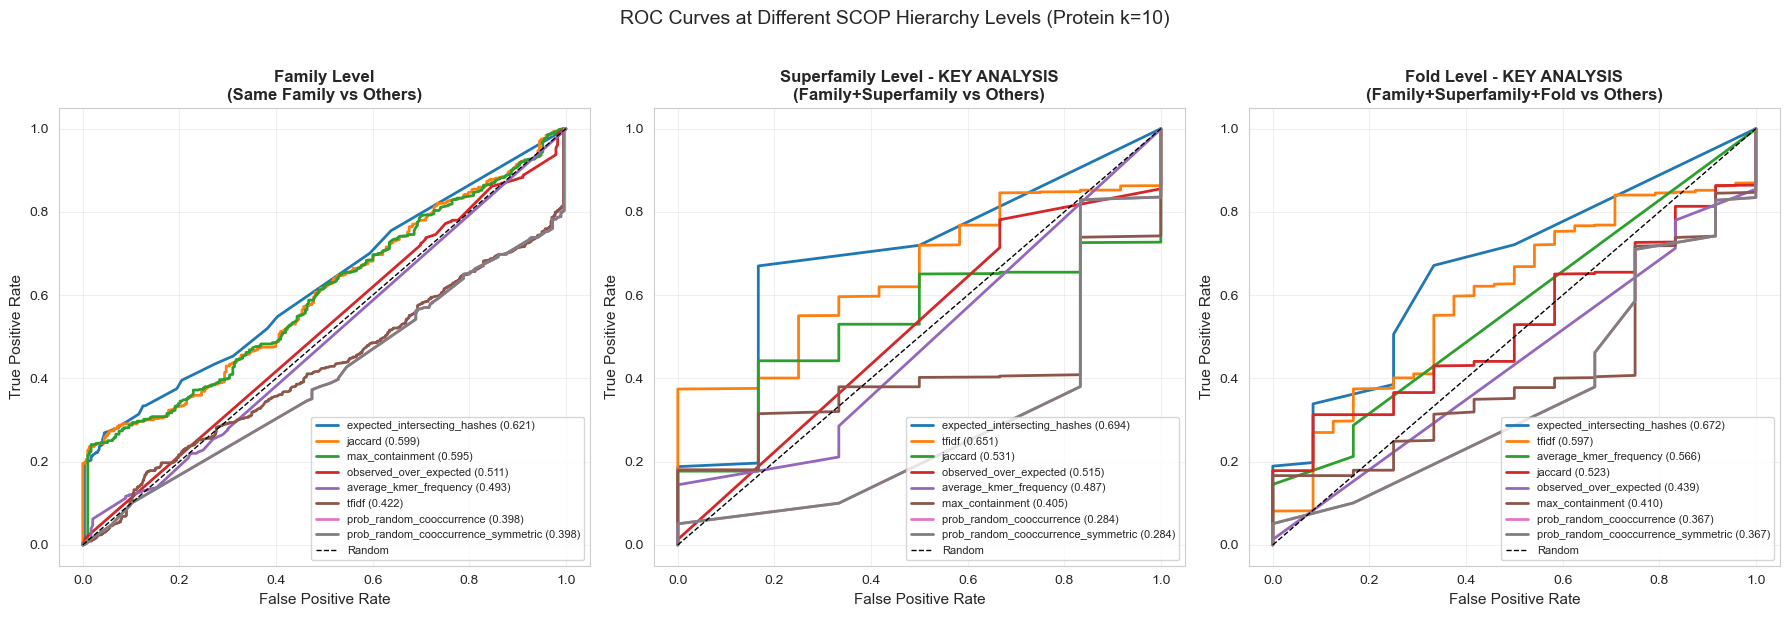

In [9]:
# Plot ROC curves for all three hierarchy levels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Family level
ax = axes[0]
for metric, results in sorted(
    auroc_results_family.items(), key=lambda x: x[1]["auroc"], reverse=True
):
    ax.plot(
        results["fpr"],
        results["tpr"],
        label=f"{metric} ({results['auroc']:.3f})",
        linewidth=2,
    )
ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Family Level\n(Same Family vs Others)", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

# Superfamily level
ax = axes[1]
for metric, results in sorted(
    auroc_results_superfamily.items(), key=lambda x: x[1]["auroc"], reverse=True
):
    ax.plot(
        results["fpr"],
        results["tpr"],
        label=f"{metric} ({results['auroc']:.3f})",
        linewidth=2,
    )
ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(
    "Superfamily Level - KEY ANALYSIS\n(Family+Superfamily vs Others)",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

# Fold level
ax = axes[2]
for metric, results in sorted(
    auroc_results_fold.items(), key=lambda x: x[1]["auroc"], reverse=True
):
    ax.plot(
        results["fpr"],
        results["tpr"],
        label=f"{metric} ({results['auroc']:.3f})",
        linewidth=2,
    )
ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(
    "Fold Level - KEY ANALYSIS\n(Family+Superfamily+Fold vs Others)",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

plt.suptitle(
    "ROC Curves at Different SCOP Hierarchy Levels (Protein k=10)", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [10]:
# Calculate average values by relationship - FOCUS ON SUPERFAMILY AND FOLD
# Using boolean columns directly: same_family, same_superfamily, same_fold
print("=" * 100)
print("AVERAGE METRIC VALUES BY RELATIONSHIP - FOCUS ON SUPERFAMILY AND FOLD")
print("Binary classification: same_X=True vs same_X=False")
print("=" * 100)

summary_data = []
for metric in metrics:
    if metric in df_k10.columns:
        stats_dict = {"metric": metric}

        # Calculate stats for each binary relationship
        # Family: same_family=True vs same_family=False
        family_true = df_k10.filter(pl.col("same_family") == True).select(metric)
        family_false = df_k10.filter(pl.col("same_family") == False).select(metric)

        # Superfamily: same_superfamily=True vs same_superfamily=False
        superfamily_true = df_k10.filter(pl.col("same_superfamily") == True).select(
            metric
        )
        superfamily_false = df_k10.filter(pl.col("same_superfamily") == False).select(
            metric
        )

        # Fold: same_fold=True vs same_fold=False
        fold_true = df_k10.filter(pl.col("same_fold") == True).select(metric)
        fold_false = df_k10.filter(pl.col("same_fold") == False).select(metric)

        # Calculate statistics for each group
        if family_true.height > 0:
            stats_dict["same_family_mean"] = family_true.select(pl.col(metric).mean())[
                0, 0
            ]
            stats_dict["same_family_median"] = family_true.select(
                pl.col(metric).median()
            )[0, 0]
            stats_dict["same_family_count"] = family_true.height

        if family_false.height > 0:
            stats_dict["not_same_family_mean"] = family_false.select(
                pl.col(metric).mean()
            )[0, 0]
            stats_dict["not_same_family_median"] = family_false.select(
                pl.col(metric).median()
            )[0, 0]
            stats_dict["not_same_family_count"] = family_false.height

        if superfamily_true.height > 0:
            stats_dict["same_superfamily_mean"] = superfamily_true.select(
                pl.col(metric).mean()
            )[0, 0]
            stats_dict["same_superfamily_median"] = superfamily_true.select(
                pl.col(metric).median()
            )[0, 0]
            stats_dict["same_superfamily_count"] = superfamily_true.height

        if superfamily_false.height > 0:
            stats_dict["not_same_superfamily_mean"] = superfamily_false.select(
                pl.col(metric).mean()
            )[0, 0]
            stats_dict["not_same_superfamily_median"] = superfamily_false.select(
                pl.col(metric).median()
            )[0, 0]
            stats_dict["not_same_superfamily_count"] = superfamily_false.height

        if fold_true.height > 0:
            stats_dict["same_fold_mean"] = fold_true.select(pl.col(metric).mean())[0, 0]
            stats_dict["same_fold_median"] = fold_true.select(pl.col(metric).median())[
                0, 0
            ]
            stats_dict["same_fold_count"] = fold_true.height

        if fold_false.height > 0:
            stats_dict["not_same_fold_mean"] = fold_false.select(pl.col(metric).mean())[
                0, 0
            ]
            stats_dict["not_same_fold_median"] = fold_false.select(
                pl.col(metric).median()
            )[0, 0]
            stats_dict["not_same_fold_count"] = fold_false.height

        summary_data.append(stats_dict)

summary_df = pd.DataFrame(summary_data).set_index("metric")

# Calculate fold changes: same_X vs not_same_X
if (
    "same_family_mean" in summary_df.columns
    and "not_same_family_mean" in summary_df.columns
):
    summary_df["family_true_vs_false"] = (
        summary_df["same_family_mean"] / summary_df["not_same_family_mean"]
    )

if (
    "same_superfamily_mean" in summary_df.columns
    and "not_same_superfamily_mean" in summary_df.columns
):
    summary_df["superfamily_true_vs_false"] = (
        summary_df["same_superfamily_mean"] / summary_df["not_same_superfamily_mean"]
    )

if (
    "same_fold_mean" in summary_df.columns
    and "not_same_fold_mean" in summary_df.columns
):
    summary_df["fold_true_vs_false"] = (
        summary_df["same_fold_mean"] / summary_df["not_same_fold_mean"]
    )

print("\nMean values by binary relationship:")
print("\nSUPERFAMILY (same_superfamily: True vs False):")
superfamily_cols = [
    c for c in summary_df.columns if "superfamily" in c and "_mean" in c
]
if superfamily_cols:
    print(summary_df[superfamily_cols].round(4))

print("\nFOLD (same_fold: True vs False):")
fold_cols = [c for c in summary_df.columns if "fold" in c and "_mean" in c]
if fold_cols:
    print(summary_df[fold_cols].round(4))

print("\nFAMILY (same_family: True vs False):")
family_cols = [c for c in summary_df.columns if "family" in c and "_mean" in c]
if family_cols:
    print(summary_df[family_cols].round(4))

print("\n\nFold changes (True vs False):")
ratio_cols = [c for c in summary_df.columns if "_true_vs_false" in c]
if ratio_cols:
    print(
        summary_df[ratio_cols]
        .sort_values("superfamily_true_vs_false", ascending=False)
        .round(2)
    )

summary_df

AVERAGE METRIC VALUES BY RELATIONSHIP - FOCUS ON SUPERFAMILY AND FOLD
Binary classification: same_X=True vs same_X=False

Mean values by binary relationship:

SUPERFAMILY (same_superfamily: True vs False):
                                    same_superfamily_mean  \
metric                                                      
jaccard                                            0.0281   
max_containment                                    0.1188   
tfidf                                           2474.7560   
average_kmer_frequency                             0.0002   
prob_random_cooccurrence                           0.0001   
prob_random_cooccurrence_symmetric                 0.0001   
expected_intersecting_hashes                       0.0009   
observed_over_expected                          6733.7081   

                                    not_same_superfamily_mean  
metric                                                         
jaccard                                                

,same_family_mean,same_family_median,same_family_count,not_same_family_mean,not_same_family_median,not_same_family_count,same_superfamily_mean,same_superfamily_median,same_superfamily_count,not_same_superfamily_mean,...,not_same_superfamily_count,same_fold_mean,same_fold_median,same_fold_count,not_same_fold_mean,not_same_fold_median,not_same_fold_count,family_true_vs_false,superfamily_true_vs_false,fold_true_vs_false
metric,,,,,,,,,,,,,,,,,,,,,
jaccard,0.038163,4.228330e-03,1282,0.005769,3.344482e-03,586,0.028147,4.036364e-03,1856,0.005324,...,12,0.028300,4.020105e-03,1844,0.005007,0.004129,24,6.615667,5.287399,5.651650
max_containment,0.163092,8.733624e-03,1282,0.019619,7.017544e-03,586,0.118754,8.275878e-03,1856,0.014487,...,12,0.119397,8.264463e-03,1844,0.017216,0.011947,24,8.313085,8.197533,6.935138
tfidf,2358.425513,2.322239e+03,1282,2714.891467,2.521721e+03,586,2474.755978,2.386243e+03,1856,1773.401039,...,12,2476.141283,2.391057e+03,1844,2017.640859,2054.439301,24,0.868700,1.395486,1.227246
average_kmer_frequency,0.000162,1.317783e-04,1282,0.000160,1.317783e-04,586,0.000161,1.317783e-04,1856,0.000154,...,12,0.000161,1.317783e-04,1844,0.000143,0.000132,24,1.012703,1.048565,1.130565
prob_random_cooccurrence,0.000057,1.736553e-08,1282,0.000073,5.209660e-08,586,0.000061,1.736553e-08,1856,0.000132,...,12,0.000061,1.736553e-08,1844,0.000099,0.000132,24,0.774005,0.466651,0.621903
prob_random_cooccurrence_symmetric,0.000057,1.736553e-08,1282,0.000073,5.209660e-08,586,0.000061,1.736553e-08,1856,0.000132,...,12,0.000061,1.736553e-08,1844,0.000099,0.000132,24,0.774005,0.466651,0.621903
expected_intersecting_hashes,0.001186,3.953350e-04,1282,0.000415,2.635567e-04,586,0.000948,3.294459e-04,1856,0.000307,...,12,0.000952,3.294459e-04,1844,0.000297,0.000165,24,2.859343,3.082897,3.211617
observed_over_expected,6736.602240,7.588500e+03,1282,6727.614480,7.588500e+03,586,6733.708059,7.588500e+03,1856,6745.333333,...,12,6728.145422,7.588500e+03,1844,7166.916667,7588.500000,24,1.001336,0.998277,0.938778


TESTING DERIVED METRIC: Average K-mer Rarity

average_kmer_rarity = n_intersecting_hashes / expected_intersecting_hashes
(Inverse of average commonness)

Testing AUROC for average_kmer_rarity:
  Family         : AUROC = 0.5106
  Superfamily    : AUROC = 0.5153
  Fold           : AUROC = 0.4385

For comparison, expected_intersecting_hashes:
  Family         : AUROC = 0.6211
  Superfamily    : AUROC = 0.6937
  Fold           : AUROC = 0.6719


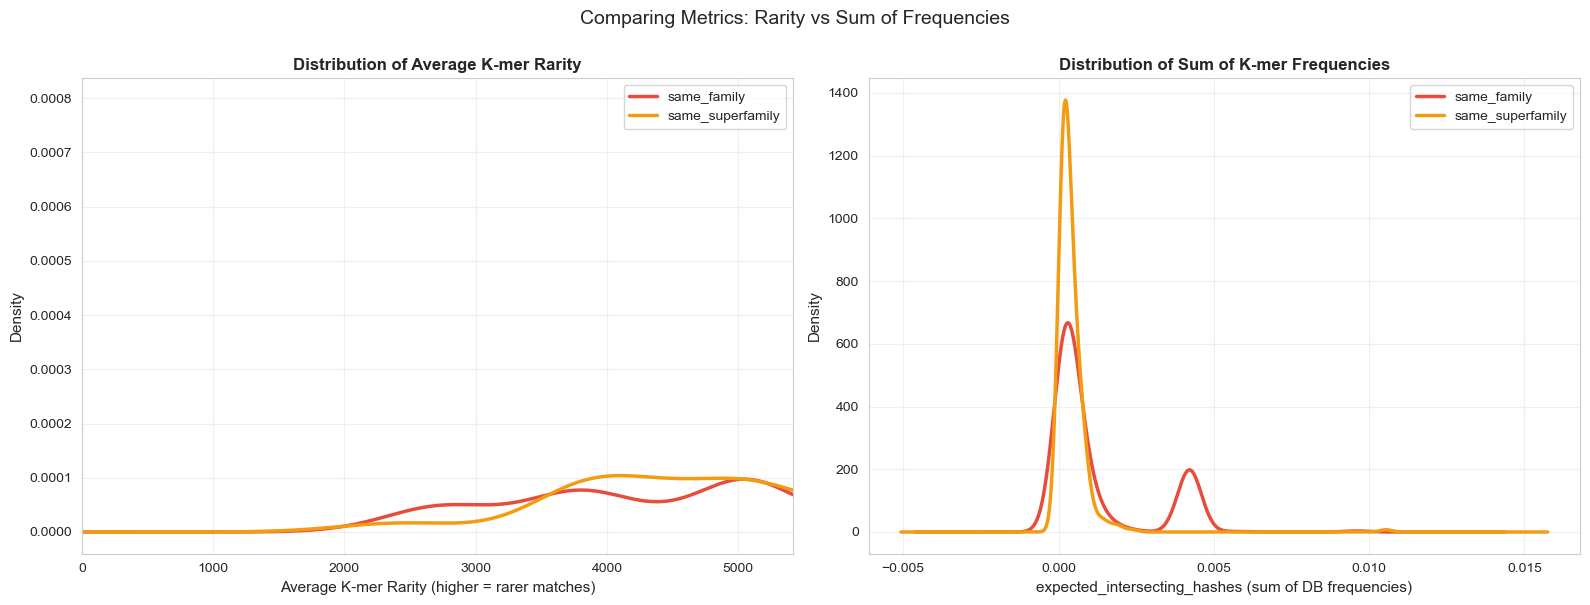


CONCLUSION:
expected_intersecting_hashes works because it's correlated with NUMBER of matches
True homologs → many matches → high sum (even if individual k-mers vary in rarity)
Random matches → few matches → low sum

The name is misleading - it's not about 'expectation', it's a SUM that scales with match count!

Consider: The metric might be better named 'sum_database_frequencies_of_matches'
or 'total_kmer_commonness' to avoid confusion with statistical expectation.


In [11]:
# Create a derived metric: Average K-mer Rarity (inverse of commonness)
# This might be even better for homology detection!

if (
    "expected_intersecting_hashes" in df_k10.columns
    and "n_intersecting_hashes" in df_k10.columns
):

    print("=" * 100)
    print("TESTING DERIVED METRIC: Average K-mer Rarity")
    print("=" * 100)
    print(
        "\naverage_kmer_rarity = n_intersecting_hashes / expected_intersecting_hashes"
    )
    print("(Inverse of average commonness)")

    # Calculate rarity
    df_k10 = df_k10.with_columns(
        (
            pl.col("n_intersecting_hashes") / pl.col("expected_intersecting_hashes")
        ).alias("average_kmer_rarity")
    )

    # Test AUROC for this derived metric
    print("\nTesting AUROC for average_kmer_rarity:")

    for level_name, positive_col in [
        ("Family", "same_family"),
        ("Superfamily", "same_superfamily"),
        ("Fold", "same_fold"),
    ]:
        auroc, _, _ = calculate_auroc_for_metric(
            df_k10, "average_kmer_rarity", positive_col
        )
        if auroc:
            print(f"  {level_name:15s}: AUROC = {auroc:.4f}")

    # Compare to expected_intersecting_hashes
    print("\nFor comparison, expected_intersecting_hashes:")
    for level_name, positive_col in [
        ("Family", "same_family"),
        ("Superfamily", "same_superfamily"),
        ("Fold", "same_fold"),
    ]:
        auroc, _, _ = calculate_auroc_for_metric(
            df_k10, "expected_intersecting_hashes", positive_col
        )
        if auroc:
            print(f"  {level_name:15s}: AUROC = {auroc:.4f}")

    # Visualize distributions
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    relationships = ["same_family", "same_superfamily", "same_fold", "different"]
    colors = {
        "same_family": "#e74c3c",
        "same_superfamily": "#f39c12",
        "same_fold": "#3498db",
        "different": "#95a5a6",
    }

    # Plot average_kmer_rarity
    ax = axes[0]
    for rel in relationships:
        data = (
            df_k10.filter(pl.col("relationship") == rel)
            .select("average_kmer_rarity")
            .to_series()
        )
        if len(data) > 0:
            data_clean = data.drop_nulls()
            if len(data_clean) > 0:
                try:
                    pd.Series(data_clean.to_list()).plot.kde(
                        ax=ax, label=rel, color=colors[rel], linewidth=2.5
                    )
                except (ValueError, np.linalg.LinAlgError):
                    # Skip KDE if data has zero variance
                    pass

    ax.set_xlabel("Average K-mer Rarity (higher = rarer matches)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("Distribution of Average K-mer Rarity", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, ax.get_xlim()[1] * 0.5])  # Zoom in on main distribution

    # Plot expected_intersecting_hashes for comparison
    ax = axes[1]
    for rel in relationships:
        data = (
            df_k10.filter(pl.col("relationship") == rel)
            .select("expected_intersecting_hashes")
            .to_series()
        )
        if len(data) > 0:
            data_clean = data.drop_nulls()
            if len(data_clean) > 0:
                try:
                    pd.Series(data_clean.to_list()).plot.kde(
                        ax=ax, label=rel, color=colors[rel], linewidth=2.5
                    )
                except (ValueError, np.linalg.LinAlgError):
                    # Skip KDE if data has zero variance
                    pass

    ax.set_xlabel("expected_intersecting_hashes (sum of DB frequencies)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(
        "Distribution of Sum of K-mer Frequencies", fontsize=12, fontweight="bold"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle("Comparing Metrics: Rarity vs Sum of Frequencies", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 100)
    print("CONCLUSION:")
    print("=" * 100)
    print(
        "expected_intersecting_hashes works because it's correlated with NUMBER of matches"
    )
    print(
        "True homologs → many matches → high sum (even if individual k-mers vary in rarity)"
    )
    print("Random matches → few matches → low sum")
    print(
        "\nThe name is misleading - it's not about 'expectation', it's a SUM that scales with match count!"
    )
    print(
        "\nConsider: The metric might be better named 'sum_database_frequencies_of_matches'"
    )
    print("or 'total_kmer_commonness' to avoid confusion with statistical expectation.")

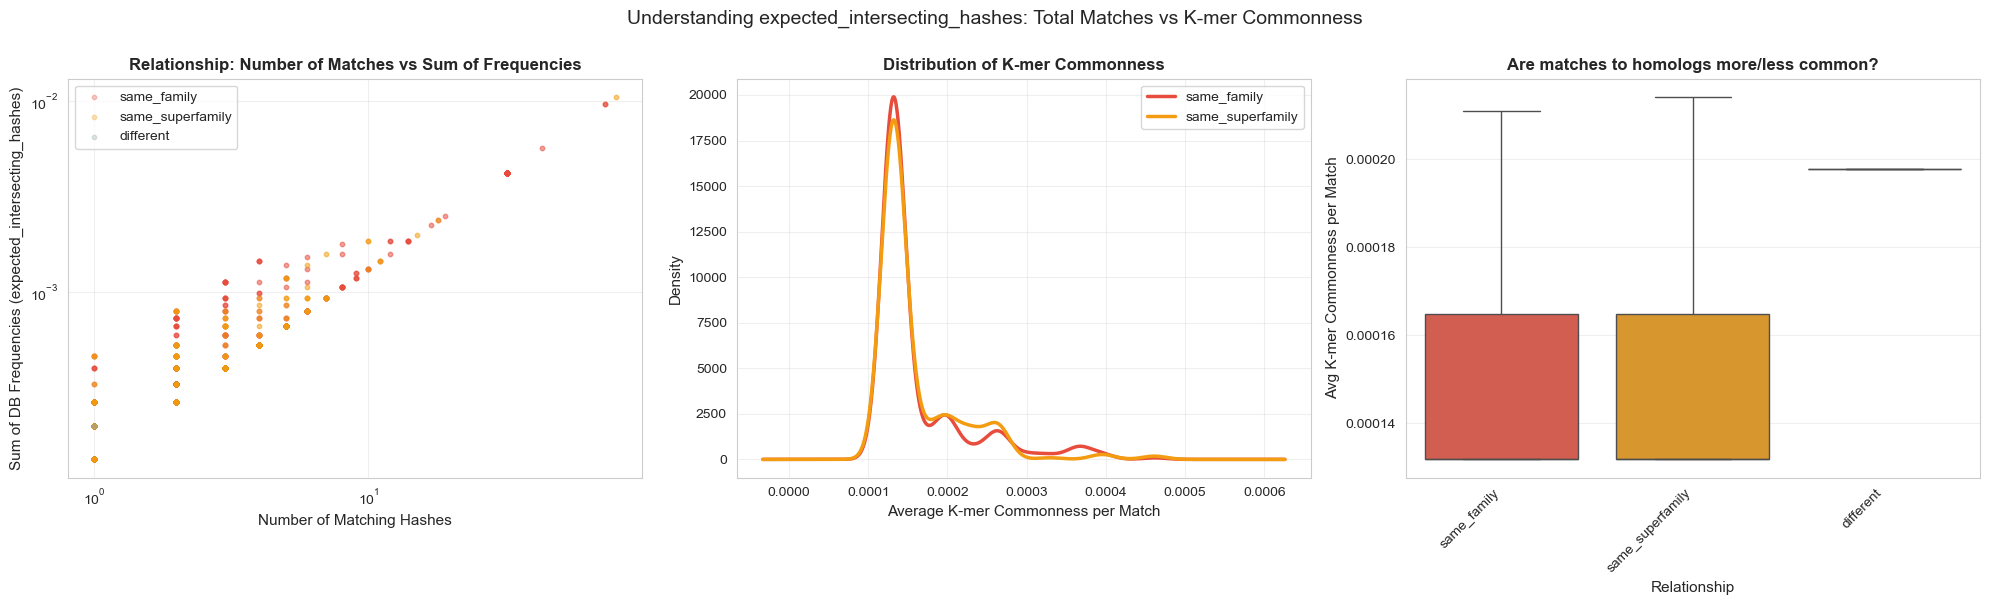


STATISTICAL TEST: Are homolog matches more common or rare on average?

same_family:
  Median commonness: 0.000132
  Different median:  0.000198
  Ratio: 0.667x
  → Homolog matches use RARER k-mers on average

same_superfamily:
  Median commonness: 0.000132
  Different median:  0.000198
  Ratio: 0.667x
  → Homolog matches use RARER k-mers on average


In [12]:
# Visualize the relationship between n_intersecting_hashes and expected_intersecting_hashes
if (
    "expected_intersecting_hashes" in df_k10.columns
    and "n_intersecting_hashes" in df_k10.columns
):

    # Create avg_kmer_commonness if it does not exist
    if "avg_kmer_commonness" not in df_k10.columns:
        df_k10 = df_k10.with_columns(
            (
                pl.col("expected_intersecting_hashes") / pl.col("n_intersecting_hashes")
            ).alias("avg_kmer_commonness")
        )

    # Sample for visualization
    sample_viz = min(20000, df_k10.height)
    df_viz = df_k10.sample(n=sample_viz, seed=42)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot 1: Scatter of n_intersecting vs expected_intersecting
    ax = axes[0]
    relationships = ["same_family", "same_superfamily", "same_fold", "different"]
    colors = {
        "same_family": "#e74c3c",
        "same_superfamily": "#f39c12",
        "same_fold": "#3498db",
        "different": "#95a5a6",
    }

    for rel in relationships:
        df_rel = df_viz.filter(pl.col("relationship") == rel)
        if df_rel.height > 0:
            pdf = df_rel.select(
                ["n_intersecting_hashes", "expected_intersecting_hashes"]
            ).to_pandas()
            ax.scatter(
                pdf["n_intersecting_hashes"],
                pdf["expected_intersecting_hashes"],
                alpha=0.3,
                s=10,
                label=rel,
                color=colors[rel],
            )

    ax.set_xlabel("Number of Matching Hashes", fontsize=11)
    ax.set_ylabel("Sum of DB Frequencies (expected_intersecting_hashes)", fontsize=11)
    ax.set_title(
        "Relationship: Number of Matches vs Sum of Frequencies",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Plot 2: Average commonness per match
    ax = axes[1]
    for rel in relationships:
        df_rel = df_viz.filter(pl.col("relationship") == rel)
        if df_rel.height > 0 and "avg_kmer_commonness" in df_rel.columns:
            pdf = df_rel.select(["avg_kmer_commonness"]).to_pandas()
            data = pdf["avg_kmer_commonness"].dropna()
            if len(data) > 0:
                try:
                    data.plot.kde(ax=ax, label=rel, color=colors[rel], linewidth=2.5)
                except (ValueError, np.linalg.LinAlgError):
                    # Skip KDE if data has zero variance
                    pass

    ax.set_xlabel("Average K-mer Commonness per Match", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("Distribution of K-mer Commonness", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: Box plot showing the difference
    ax = axes[2]
    pdf_all = df_viz.select(["relationship", "avg_kmer_commonness"]).to_pandas()
    pdf_all = pdf_all[pdf_all["relationship"].isin(relationships)]

    sns.boxplot(
        data=pdf_all,
        x="relationship",
        y="avg_kmer_commonness",
        ax=ax,
        palette=colors,
        showfliers=False,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Relationship", fontsize=11)
    ax.set_ylabel("Avg K-mer Commonness per Match", fontsize=11)
    ax.set_title(
        "Are matches to homologs more/less common?", fontsize=12, fontweight="bold"
    )
    ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        "Understanding expected_intersecting_hashes: Total Matches vs K-mer Commonness",
        fontsize=14,
        y=1.00,
    )
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 100)
    print("STATISTICAL TEST: Are homolog matches more common or rare on average?")
    print("=" * 100)

    for rel in ["same_family", "same_superfamily", "same_fold"]:
        same_data = (
            df_k10.filter(pl.col("relationship") == rel)
            .select("avg_kmer_commonness")
            .to_series()
        )
        diff_data = (
            df_k10.filter(pl.col("relationship") == "different")
            .select("avg_kmer_commonness")
            .to_series()
        )

        if len(same_data) > 0 and len(diff_data) > 0:
            same_median = same_data.median()
            diff_median = diff_data.median()
            ratio = same_median / diff_median if diff_median > 0 else 0

            print(f"\n{rel}:")
            print(f"  Median commonness: {same_median:.6f}")
            print(f"  Different median:  {diff_median:.6f}")
            print(f"  Ratio: {ratio:.3f}x")
            if ratio > 1:
                print(f"  → Homolog matches use MORE COMMON k-mers on average")
            else:
                print(f"  → Homolog matches use RARER k-mers on average")

In [13]:
# INVESTIGATE: Why does expected_intersecting_hashes perform well?
# It should be HIGH for common matches, so why does it discriminate homologs?

print("=" * 100)
print("INVESTIGATING: expected_intersecting_hashes paradox")
print("=" * 100)

# Let's look at the relationship between n_intersecting_hashes and expected_intersecting_hashes
if (
    "expected_intersecting_hashes" in df_k10.columns
    and "n_intersecting_hashes" in df_k10.columns
):

    # Calculate average k-mer frequency (commonness) per match
    df_k10 = df_k10.with_columns(
        (
            pl.col("expected_intersecting_hashes") / pl.col("n_intersecting_hashes")
        ).alias("avg_kmer_commonness")
    )

    print("\nAverage k-mer commonness by relationship:")
    stats = (
        df_k10.group_by("relationship")
        .agg(
            [
                pl.col("expected_intersecting_hashes").mean().alias("mean_sum_freq"),
                pl.col("n_intersecting_hashes").mean().alias("mean_n_matches"),
                pl.col("avg_kmer_commonness").mean().alias("mean_commonness_per_match"),
                pl.count().alias("count"),
            ]
        )
        .sort("relationship")
    )

    print(stats)

    print("\n" + "=" * 100)
    print("KEY INSIGHT:")
    print("=" * 100)
    print("expected_intersecting_hashes = sum of DB frequencies for matching k-mers")
    print("\nHypothesis: True homologs have:")
    print("  - MORE total matches (higher n_intersecting_hashes)")
    print("  - These matches include BOTH common AND rare k-mers")
    print("  - So expected_intersecting_hashes is HIGH because there are MANY matches")
    print("\nRandom matches have:")
    print("  - FEWER total matches")
    print("  - Only the most common k-mers")
    print(
        "  - So expected_intersecting_hashes is LOWER (fewer matches total, even if common)"
    )
    print(
        "\nThe metric works because: more matches → higher sum, even if some are rare!"
    )
else:
    print("Columns not found in dataframe")

INVESTIGATING: expected_intersecting_hashes paradox

Average k-mer commonness by relationship:
shape: (4, 5)
┌──────────────────┬───────────────┬────────────────┬───────────────────────────┬───────┐
│ relationship     ┆ mean_sum_freq ┆ mean_n_matches ┆ mean_commonness_per_match ┆ count │
│ ---              ┆ ---           ┆ ---            ┆ ---                       ┆ ---   │
│ str              ┆ f64           ┆ f64            ┆ f64                       ┆ u32   │
╞══════════════════╪═══════════════╪════════════════╪═══════════════════════════╪═══════╡
│ different        ┆ 0.000198      ┆ 1.0            ┆ 0.000198                  ┆ 2     │
│ same_class       ┆ 0.000132      ┆ 1.0            ┆ 0.000132                  ┆ 2     │
│ same_family      ┆ 0.001186      ┆ 8.50078        ┆ 0.000162                  ┆ 1282  │
│ same_superfamily ┆ 0.000416      ┆ 2.697595       ┆ 0.00016                   ┆ 582   │
└──────────────────┴───────────────┴────────────────┴───────────────────────────┴

In [15]:
# # Using binary classification: same_X=True vs same_X=False
# import numpy as np
# (Binary: True=solid, False=dashed)", fontsize=11)
#         ax.legend(fontsize=8, loc='best')
#         ax.grid(True, alpha=0.3)

#         # Add vertical lines for means of superfamily and fold (emphasized levels)
#         if len(superfamily_true) > 0:
#             ax.axvline(superfamily_true.mean(), color="#f39c12", linestyle='-', alpha=0.3, linewidth=1)
#         if len(fold_true) > 0:
#             ax.axvline(fold_true.mean(), color="#3498db", linestyle='-', alpha=0.3, linewidth=1)

# plt.suptitle('Metric Distributions by Binary Relationship (Protein k=10)\n' +
#              'Binary Classification: same_X=True (solid) vs same_X=False (dashed)\n' +
#              'Emphasizing Superfamily (orange) and Fold (blue)',
#              fontsize=13, y=0.998)
# plt.tight_layout()
# plt.show()

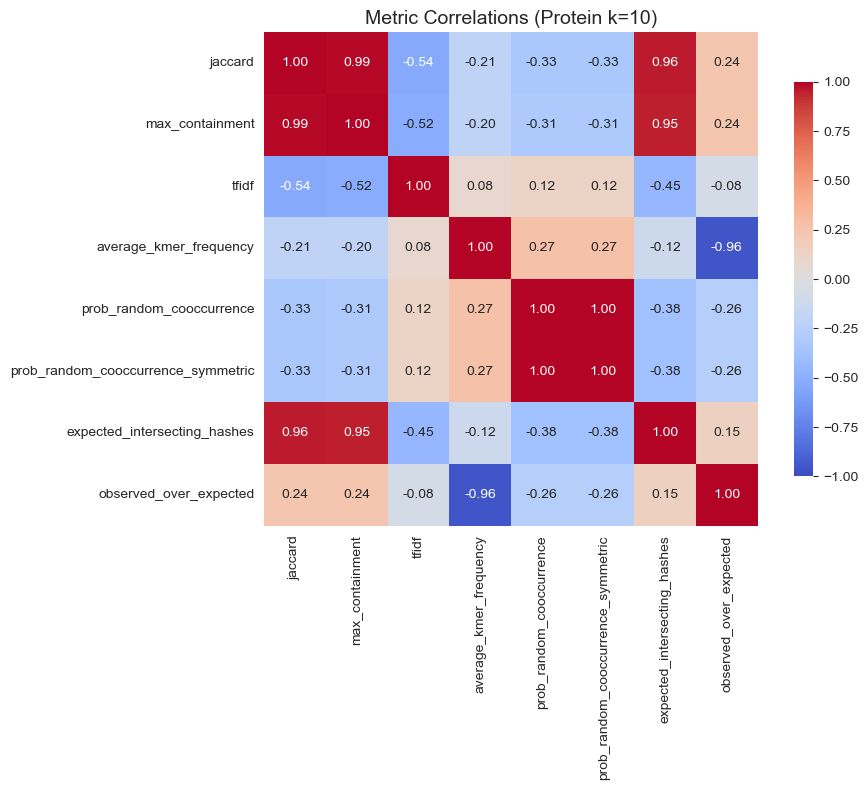

In [16]:
# Metric correlations
correlation_metrics = [m for m in metrics if m in df_k10.columns]

if len(correlation_metrics) > 1:
    corr_df = df_k10.select(correlation_metrics).to_pandas().corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        ax=ax,
        cbar_kws={"shrink": 0.8},
        vmin=-1,
        vmax=1,
    )
    ax.set_title("Metric Correlations (Protein k=10)", fontsize=14)
    plt.tight_layout()
    plt.show()

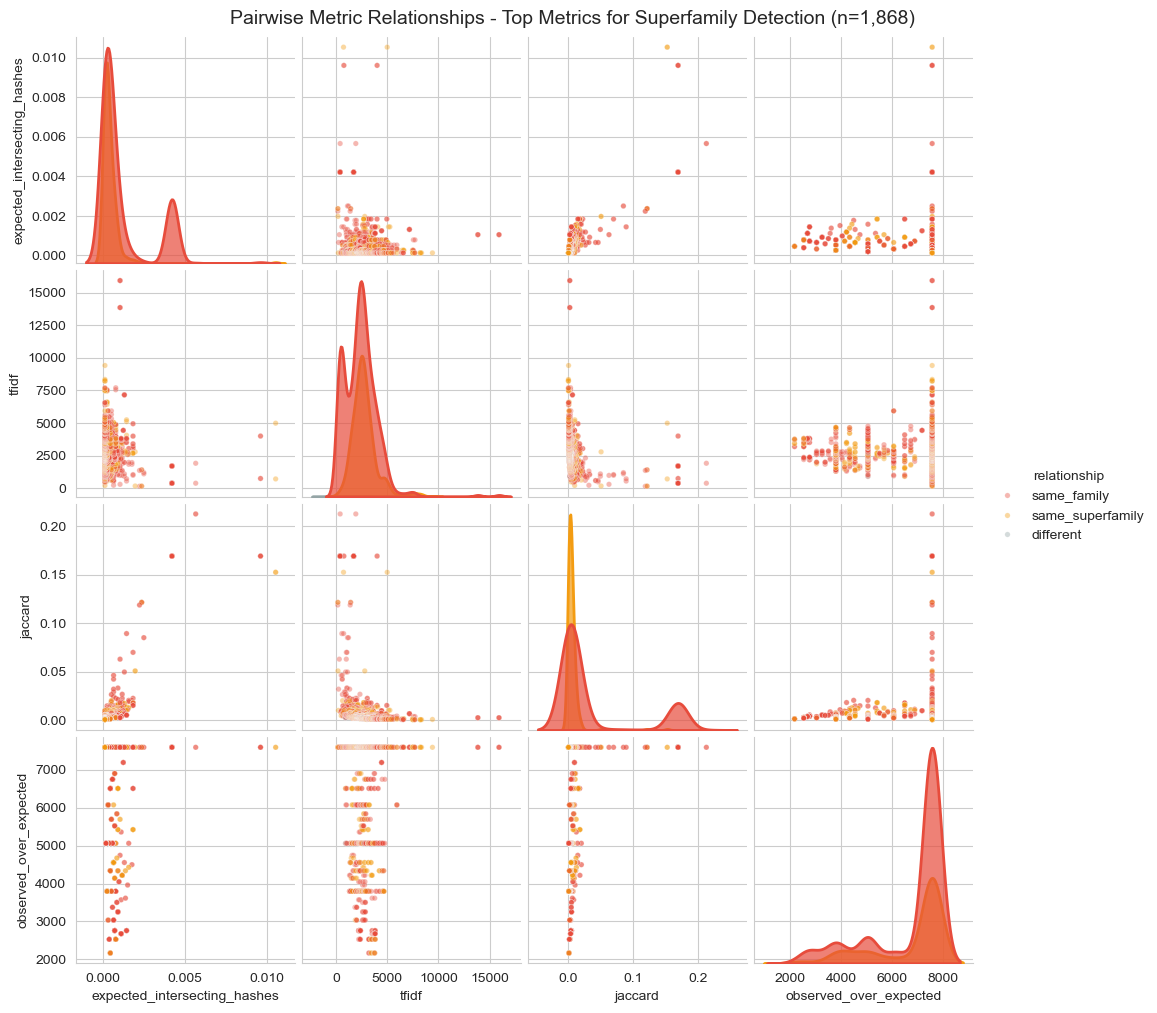

In [17]:
# Pairwise scatter plots showing relationship between top metrics
# Sample from protein_k10 for visualization
sample_size = min(20000, df_k10.height)
df_sample = df_k10.sample(n=sample_size, seed=42)

# Get top 4 metrics based on superfamily AUROC
top_metrics_superfamily = sorted(
    auroc_results_superfamily.items(), key=lambda x: x[1]["auroc"], reverse=True
)[:4]
top_metric_names = [m[0] for m in top_metrics_superfamily]

if len(top_metric_names) >= 2:
    pdf_sample = df_sample.select(top_metric_names + ["relationship"]).to_pandas()

    # Filter to key relationships
    pdf_sample = pdf_sample[
        pdf_sample["relationship"].isin(
            ["same_family", "same_superfamily", "same_fold", "different"]
        )
    ]

    # Create pairplot
    g = sns.pairplot(
        pdf_sample,
        hue="relationship",
        vars=top_metric_names,
        diag_kind="kde",
        palette={
            "same_family": "#e74c3c",
            "same_superfamily": "#f39c12",
            "same_fold": "#3498db",
            "different": "#95a5a6",
        },
        plot_kws={"alpha": 0.4, "s": 15},
        diag_kws={"alpha": 0.7, "linewidth": 2},
    )
    g.fig.suptitle(
        f"Pairwise Metric Relationships - Top Metrics for Superfamily Detection (n={sample_size:,})",
        y=1.01,
        fontsize=14,
    )
    plt.show()

METRIC DISTRIBUTIONS BY RELATIONSHIP LEVEL


ValueError: zero-size array to reduction operation minimum which has no identity

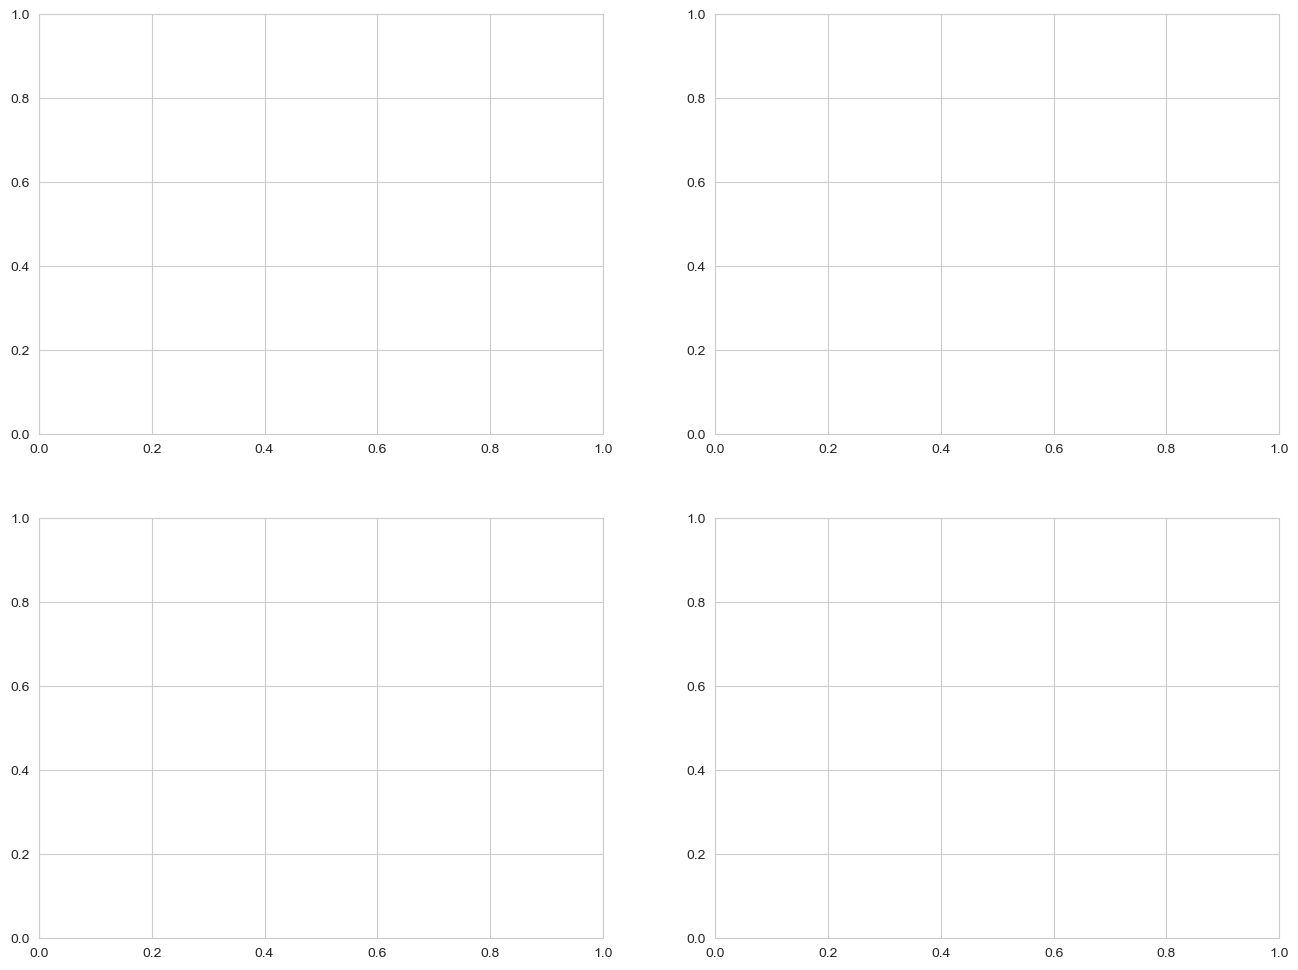

In [18]:
# Boxplots comparing metrics across relationship levels for protein_k10
print("=" * 100)
print("METRIC DISTRIBUTIONS BY RELATIONSHIP LEVEL")
print("=" * 100)

# Select top metrics for visualization
top_metrics_for_plot = ["jaccard", "max_containment", "tfidf", "observed_over_expected"]

# Sample data for faster plotting
sample_size_box = min(50000, df_k10.height)
df_box_sample = df_k10.sample(n=sample_size_box, seed=42)

# Create figure with subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

relationships_order = ["same_family", "same_superfamily", "same_fold", "different"]
colors_box = {
    "same_family": "#e74c3c",
    "same_superfamily": "#f39c12",
    "same_fold": "#3498db",
    "different": "#95a5a6",
}

for idx, metric in enumerate(top_metrics_for_plot):
    if idx >= len(axes):
        break

    ax = axes[idx]

    if metric in df_box_sample.columns:
        pdf = df_box_sample.select([metric, "relationship"]).to_pandas()
        pdf = pdf[pdf["relationship"].isin(relationships_order)]

        # Use violin plot for better distribution visualization
        parts = ax.violinplot(
            [
                pdf[pdf["relationship"] == rel][metric].dropna().values
                for rel in relationships_order
            ],
            positions=range(len(relationships_order)),
            showmeans=True,
            showmedians=True,
            widths=0.7,
        )

        # Color the violin plots
        for pc, rel in zip(parts["bodies"], relationships_order):
            pc.set_facecolor(colors_box[rel])
            pc.set_alpha(0.7)

        # Add boxplot overlay for quartiles
        bp = ax.boxplot(
            [
                pdf[pdf["relationship"] == rel][metric].dropna().values
                for rel in relationships_order
            ],
            positions=range(len(relationships_order)),
            widths=0.3,
            patch_artist=True,
            showfliers=False,  # Don't show outliers to avoid clutter
            medianprops=dict(color="red", linewidth=2),
            boxprops=dict(alpha=0.3),
        )

        ax.set_xticks(range(len(relationships_order)))
        ax.set_xticklabels(relationships_order, rotation=45, ha="right")
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(f"{metric} by Relationship", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Metric Distributions by Relationship Level (Protein k=10, n={sample_size_box:,})",
    fontsize=14,
    y=1.00,
)
plt.tight_layout()
plt.show()

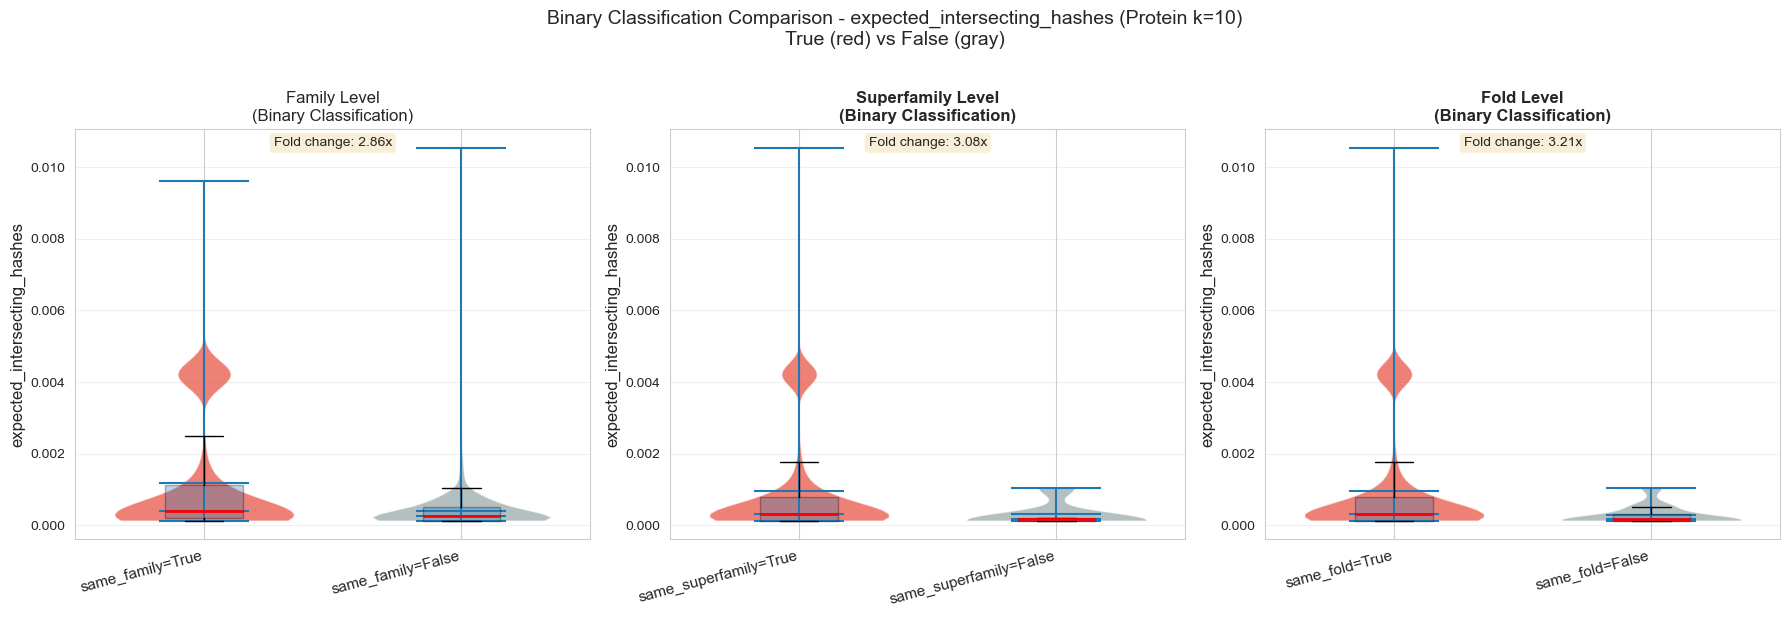

In [ ]:
# Comparison boxplots: True vs False for each hierarchy level
# Binary classification: same_X=True vs same_X=False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Use best metric for this comparison
best_metric = sorted(
    auroc_results_superfamily.items(), key=lambda x: x[1]["auroc"], reverse=True
)[0][0]

comparisons = [
    ("Family", "same_family"),
    ("Superfamily", "same_superfamily"),
    ("Fold", "same_fold"),
]

for idx, (level_name, bool_col) in enumerate(comparisons):
    ax = axes[idx]

    # Get data for True and False
    df_true = (
        df_box_sample.filter(pl.col(bool_col) == True)
        .select(best_metric)
        .to_pandas()[best_metric]
        .dropna()
    )
    df_false = (
        df_box_sample.filter(pl.col(bool_col) == False)
        .select(best_metric)
        .to_pandas()[best_metric]
        .dropna()
    )

    # Create violin plot
    parts = ax.violinplot(
        [df_true.values, df_false.values],
        positions=[0, 1],
        showmeans=True,
        showmedians=True,
        widths=0.7,
    )

    # Color the violins
    colors = ["#e74c3c", "#95a5a6"]  # True in red, False in gray
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    # Add boxplot overlay
    bp = ax.boxplot(
        [df_true.values, df_false.values],
        positions=[0, 1],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="red", linewidth=2),
        boxprops=dict(alpha=0.3),
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f"{bool_col}=True", f"{bool_col}=False"], fontsize=11, rotation=15, ha="right"
    )
    ax.set_ylabel(best_metric, fontsize=12)
    ax.set_title(
        f"{level_name} Level\n(Binary Classification)",
        fontsize=12,
        fontweight="bold" if level_name in ["Superfamily", "Fold"] else "normal",
    )
    ax.grid(True, alpha=0.3, axis="y")

    # Add statistical annotation
    mean_true = df_true.mean()
    mean_false = df_false.mean()
    fold_change = mean_true / mean_false if mean_false > 0 else 0

    ax.text(
        0.5,
        0.98,
        f"Fold change: {fold_change:.2f}x",
        transform=ax.transAxes,
        ha="center",
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        fontsize=10,
    )

plt.suptitle(
    f"Binary Classification Comparison - {best_metric} (Protein k=10)\nTrue (red) vs False (gray)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [19]:
# FILTERING STRATEGY OPTIMIZATION - Focus on Superfamily and Fold
print("=" * 100)
print("FILTERING STRATEGY OPTIMIZATION FOR SUPERFAMILY AND FOLD DETECTION")
print("=" * 100)


def test_filter_strategy(
    df, filters, metric="jaccard", positive_rel="same_superfamily"
):
    """Apply filters and calculate AUROC

    Note: positive_rel should be a single relationship for binary classification
    """
    df_filtered = df

    for col, threshold in filters.items():
        if col not in df.columns:
            continue

        if isinstance(threshold, tuple):
            min_val, max_val = threshold
            df_filtered = df_filtered.filter(
                (pl.col(col) >= min_val) & (pl.col(col) <= max_val)
            )
        else:
            df_filtered = df_filtered.filter(pl.col(col) >= threshold)

    auroc, _, _ = calculate_auroc_for_metric(df_filtered, metric, positive_rel)
    return auroc, df_filtered.height


# Test for both superfamily and fold levels - BINARY classification
for level_name, positive_col in [
    ("Superfamily", "same_superfamily"),
    ("Fold", "same_fold"),
]:
    print(f"\n{'='*100}")
    print(f"{level_name.upper()} LEVEL FILTERING")
    print(f"Binary: {positive_col}=True vs {positive_col}=False")
    print(f"{'='*100}\n")

    baseline_auroc, baseline_count = test_filter_strategy(
        df_k10, {}, positive_rel=positive_col
    )
    print(f"Baseline: AUROC = {baseline_auroc:.4f}, n = {baseline_count:,}\n")

    # Comprehensive filter strategies
    filter_strategies = [
        ("Max containment >= 0.3", {"max_containment": 0.3}),
        ("Max containment >= 0.5", {"max_containment": 0.5}),
        ("Max containment >= 0.7", {"max_containment": 0.7}),
        ("Jaccard >= 0.05", {"jaccard": 0.05}),
        ("Jaccard >= 0.1", {"jaccard": 0.1}),
        ("Jaccard >= 0.2", {"jaccard": 0.2}),
        ("Obs/Exp >= 5", {"observed_over_expected": 5}),
        ("Obs/Exp >= 10", {"observed_over_expected": 10}),
        ("Obs/Exp >= 50", {"observed_over_expected": 50}),
        ("Obs/Exp >= 100", {"observed_over_expected": 100}),
        ("TFIDF >= 3", {"tfidf": 3}),
        ("TFIDF >= 5", {"tfidf": 5}),
        ("TFIDF >= 10", {"tfidf": 10}),
        (
            "MaxCont>=0.3 & Obs/Exp>=5",
            {"max_containment": 0.3, "observed_over_expected": 5},
        ),
        (
            "MaxCont>=0.5 & Obs/Exp>=10",
            {"max_containment": 0.5, "observed_over_expected": 10},
        ),
        (
            "MaxCont>=0.7 & Obs/Exp>=50",
            {"max_containment": 0.7, "observed_over_expected": 50},
        ),
        ("Jaccard>=0.05 & TFIDF>=3", {"jaccard": 0.05, "tfidf": 3}),
        ("Jaccard>=0.1 & TFIDF>=5", {"jaccard": 0.1, "tfidf": 5}),
        ("Jaccard>=0.1 & Obs/Exp>=10", {"jaccard": 0.1, "observed_over_expected": 10}),
        ("Jaccard>=0.2 & Obs/Exp>=50", {"jaccard": 0.2, "observed_over_expected": 50}),
    ]

    results = []
    for name, filters in filter_strategies:
        auroc, count = test_filter_strategy(df_k10, filters, positive_rel=positive_col)
        if auroc is not None:
            results.append(
                {
                    "strategy": name,
                    "auroc": auroc,
                    "count": count,
                    "retention": count / baseline_count,
                    "auroc_improvement": auroc - baseline_auroc,
                }
            )

    results_df = pd.DataFrame(results).sort_values("auroc", ascending=False)
    print(f"Top 10 strategies by AUROC improvement:")
    print(results_df.head(10).to_string(index=False))

    if level_name == "Superfamily":
        superfamily_filter_results = results_df
    else:
        fold_filter_results = results_df

FILTERING STRATEGY OPTIMIZATION FOR SUPERFAMILY AND FOLD DETECTION

SUPERFAMILY LEVEL FILTERING
Binary: same_superfamily=True vs same_superfamily=False

Baseline: AUROC = 0.5305, n = 1,868

Top 10 strategies by AUROC improvement:
      strategy    auroc  count  retention  auroc_improvement
  Obs/Exp >= 5 0.530532   1868        1.0                0.0
 Obs/Exp >= 10 0.530532   1868        1.0                0.0
 Obs/Exp >= 50 0.530532   1868        1.0                0.0
Obs/Exp >= 100 0.530532   1868        1.0                0.0
    TFIDF >= 3 0.530532   1868        1.0                0.0
    TFIDF >= 5 0.530532   1868        1.0                0.0
   TFIDF >= 10 0.530532   1868        1.0                0.0

FOLD LEVEL FILTERING
Binary: same_fold=True vs same_fold=False

Baseline: AUROC = 0.5235, n = 1,868

Top 10 strategies by AUROC improvement:
      strategy  auroc  count  retention  auroc_improvement
  Obs/Exp >= 5 0.5235   1868        1.0                0.0
 Obs/Exp >= 10 0.5235 

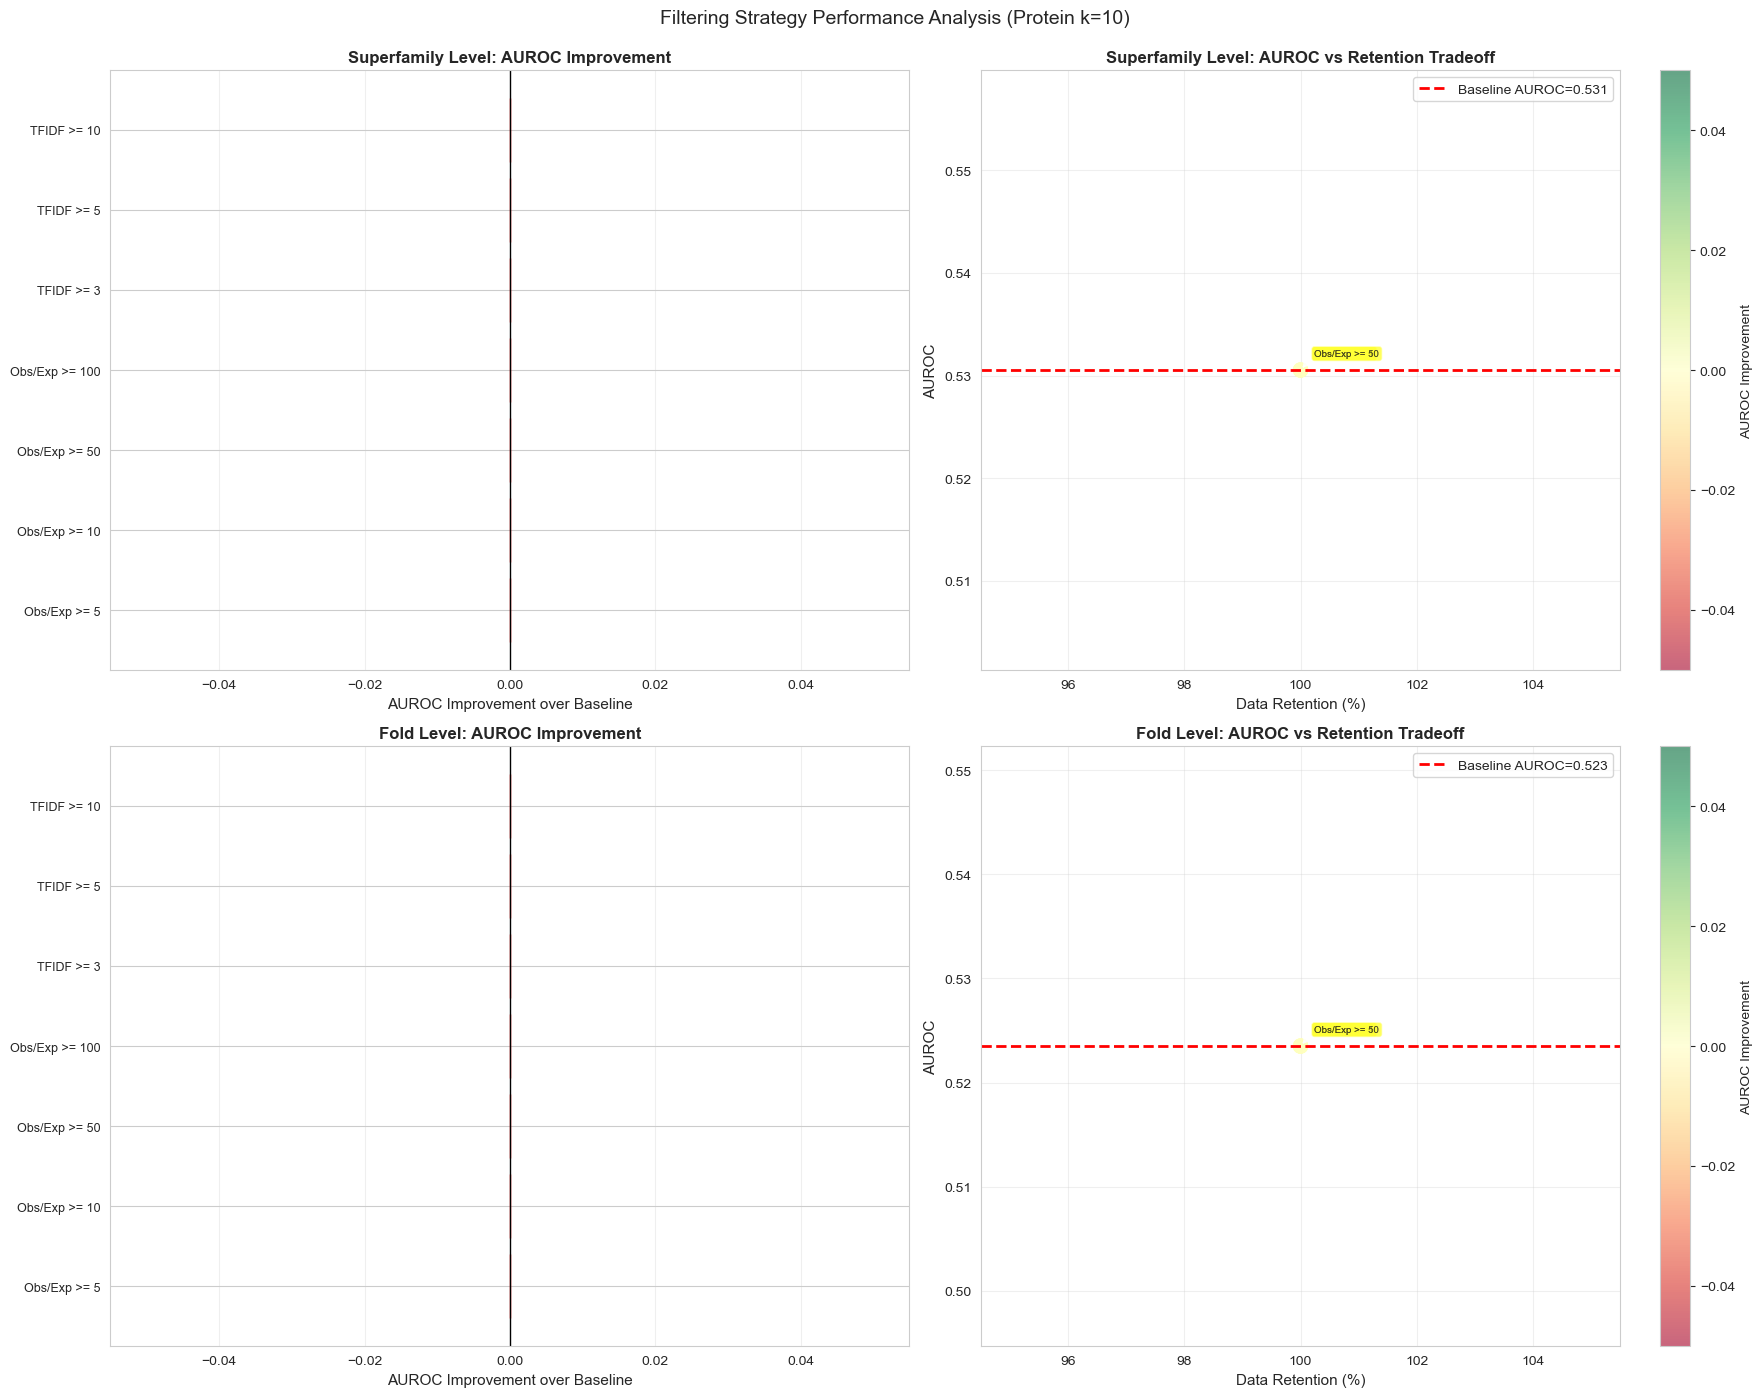

In [20]:
# Visualize filtering performance for Superfamily and Fold
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for idx, (level_name, results_df) in enumerate(
    [("Superfamily", superfamily_filter_results), ("Fold", fold_filter_results)]
):
    # AUROC improvement
    ax = axes[idx, 0]
    top_results = results_df.sort_values("auroc_improvement", ascending=True).tail(12)
    bars = ax.barh(range(len(top_results)), top_results["auroc_improvement"])
    # Color bars by improvement
    for i, (bar, improvement) in enumerate(zip(bars, top_results["auroc_improvement"])):
        bar.set_color("green" if improvement > 0 else "red")
    ax.set_yticks(range(len(top_results)))
    ax.set_yticklabels(top_results["strategy"], fontsize=9)
    ax.set_xlabel("AUROC Improvement over Baseline", fontsize=11)
    ax.set_title(
        f"{level_name} Level: AUROC Improvement", fontsize=12, fontweight="bold"
    )
    ax.axvline(0, color="black", linestyle="-", linewidth=1)
    ax.grid(True, alpha=0.3, axis="x")

    # AUROC vs Retention tradeoff
    ax = axes[idx, 1]
    scatter = ax.scatter(
        results_df["retention"] * 100,
        results_df["auroc"],
        s=100,
        alpha=0.6,
        c=results_df["auroc_improvement"],
        cmap="RdYlGn",
        vmin=-0.05,
        vmax=0.05,
    )
    baseline_auroc = (
        results_df.iloc[0]["auroc"] - results_df.iloc[0]["auroc_improvement"]
    )
    ax.axhline(
        baseline_auroc,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Baseline AUROC={baseline_auroc:.3f}",
    )
    ax.set_xlabel("Data Retention (%)", fontsize=11)
    ax.set_ylabel("AUROC", fontsize=11)
    ax.set_title(
        f"{level_name} Level: AUROC vs Retention Tradeoff",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label="AUROC Improvement")

    # Annotate top 3 improvements
    for _, row in results_df.nlargest(3, "auroc_improvement").iterrows():
        ax.annotate(
            row["strategy"],
            xy=(row["retention"] * 100, row["auroc"]),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=7,
            alpha=0.8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.4),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.3", alpha=0.5),
        )

plt.suptitle(
    "Filtering Strategy Performance Analysis (Protein k=10)", fontsize=14, y=0.995
)
plt.tight_layout()
plt.show()

In [21]:
# Load and compare multiple datasets
print("=" * 100)
print("LOADING MULTIPLE DATASETS FOR COMPARISON")
print("=" * 100)

datasets_to_load = [
    # Protein encoding (all sizes)
    "protein_k5",
    "protein_k6",
    "protein_k7",
    "protein_k8",
    "protein_k9",
    "protein_k10",
    # Dayhoff encoding (all sizes except k8 which is 22GB)
    "dayhoff_k10",
    "dayhoff_k11",
    "dayhoff_k12",
    "dayhoff_k13",
    "dayhoff_k14",
    "dayhoff_k15",
    # HP encoding (all sizes)
    "hp_k15",
    "hp_k16",
    "hp_k17",
    "hp_k18",
    "hp_k19",
    "hp_k20",
]

all_datasets = {}
MAX_ROWS = 15_000_000  # Load first 15M rows for large files

for name in datasets_to_load:
    if name in csv_files:
        filepath = data_dir / csv_files[name]
        if filepath.exists():
            size_gb = filepath.stat().st_size / 1e9

            # Determine if we need to subsample
            if size_gb < 8:
                print(f"Loading {name} ({size_gb:.2f} GB) - full dataset...")
                try:
                    df = pl.read_csv(filepath)
                    df = add_scop_columns(df)
                    all_datasets[name] = df
                    print(f"  Loaded: {df.shape[0]:,} rows (complete)")
                except Exception as e:
                    print(f"  Error loading {name}: {e}")
            else:
                print(
                    f"Loading {name} ({size_gb:.2f} GB) - sampling first {MAX_ROWS:,} rows..."
                )
                try:
                    df = pl.read_csv(filepath, n_rows=MAX_ROWS)
                    df = add_scop_columns(df)
                    all_datasets[name] = df
                    print(f"  Loaded: {df.shape[0]:,} rows (sampled)")
                except Exception as e:
                    print(f"  Error loading {name}: {e}")

print(f"\nLoaded {len(all_datasets)} datasets total")

LOADING MULTIPLE DATASETS FOR COMPARISON
Loading protein_k5 (3.08 GB) - full dataset...
  Loaded: 6,183,985 rows (complete)
Loading protein_k6 (0.22 GB) - full dataset...
  Loaded: 431,943 rows (complete)
Loading protein_k7 (0.02 GB) - full dataset...
  Loaded: 41,017 rows (complete)
Loading protein_k8 (0.00 GB) - full dataset...
  Loaded: 8,623 rows (complete)
Loading protein_k9 (0.00 GB) - full dataset...
  Loaded: 3,577 rows (complete)
Loading protein_k10 (0.00 GB) - full dataset...
  Loaded: 1,868 rows (complete)
Loading dayhoff_k10 (1.35 GB) - full dataset...
  Loaded: 2,584,617 rows (complete)
Loading dayhoff_k11 (0.33 GB) - full dataset...
  Loaded: 629,133 rows (complete)
Loading dayhoff_k12 (0.09 GB) - full dataset...
  Loaded: 161,231 rows (complete)
Loading dayhoff_k13 (0.02 GB) - full dataset...
  Loaded: 45,657 rows (complete)
Loading dayhoff_k14 (0.01 GB) - full dataset...
  Loaded: 14,940 rows (complete)
Loading dayhoff_k15 (0.00 GB) - full dataset...
  Loaded: 6,167 row

In [22]:
# Compare AUROC across all datasets at different hierarchy levels
print("=" * 100)
print("CROSS-DATASET AUROC COMPARISON")
print("Using BINARY classification for each level")
print("=" * 100)

all_results = []

for dataset_name, df in all_datasets.items():
    print(f"\nAnalyzing {dataset_name}...")

    # Test at all three hierarchy levels - BINARY classification
    for level_name, positive_col in [
        ("Family", "same_family"),
        ("Superfamily", "same_superfamily"),
        ("Fold", "same_fold"),
    ]:
        for metric in metrics:
            if metric in df.columns:
                auroc, _, _ = calculate_auroc_for_metric(df, metric, positive_col)
                if auroc is not None:
                    all_results.append(
                        {
                            "dataset": dataset_name,
                            "hierarchy": level_name,
                            "metric": metric,
                            "auroc": auroc,
                        }
                    )

all_results_df = pd.DataFrame(all_results)
print(f"\nGenerated {len(all_results_df)} AUROC measurements")
all_results_df.head(20)

CROSS-DATASET AUROC COMPARISON
Using BINARY classification for each level

Analyzing protein_k5...

Analyzing protein_k6...

Analyzing protein_k7...

Analyzing protein_k8...

Analyzing protein_k9...

Analyzing protein_k10...

Analyzing dayhoff_k10...

Analyzing dayhoff_k11...

Analyzing dayhoff_k12...

Analyzing dayhoff_k13...

Analyzing dayhoff_k14...

Analyzing dayhoff_k15...

Analyzing hp_k15...

Analyzing hp_k16...

Analyzing hp_k17...

Analyzing hp_k18...

Analyzing hp_k19...

Analyzing hp_k20...

Generated 417 AUROC measurements


,dataset,hierarchy,metric,auroc
0,protein_k5,Family,jaccard,0.512106
1,protein_k5,Family,max_containment,0.507790
2,protein_k5,Family,tfidf,0.499017
3,protein_k5,Family,average_kmer_frequency,0.508230
4,protein_k5,Family,prob_random_cooccurrence,0.493985
5,protein_k5,Family,prob_random_cooccurrence_symmetric,0.493985
6,protein_k5,Family,expected_intersecting_hashes,0.513853
7,protein_k5,Family,observed_over_expected,0.491758
8,protein_k5,Superfamily,jaccard,0.455379
9,protein_k5,Superfamily,max_containment,0.441106


In [23]:
# COMPREHENSIVE BOXPLOTS: All encodings and k-sizes
print("=" * 100)
print("CROSS-DATASET METRIC COMPARISONS BY RELATIONSHIP")
print("=" * 100)

# Select best metric based on AUROC
best_metric_overall = sorted(
    auroc_results_superfamily.items(), key=lambda x: x[1]["auroc"], reverse=True
)[0][0]

print(f"\nUsing metric: {best_metric_overall}")
print(
    f"(Best AUROC for superfamily detection: {auroc_results_superfamily[best_metric_overall]['auroc']:.4f})"
)

# Prepare data for all datasets
all_boxplot_data = []

for dataset_name, df in all_datasets.items():
    print(f"Sampling {dataset_name}...")

    # Sample to keep memory manageable
    sample_size = min(30000, df.height)
    df_sample = df.sample(n=sample_size, seed=42)

    if best_metric_overall in df_sample.columns:
        pdf = df_sample.select([best_metric_overall, "relationship"]).to_pandas()
        pdf["dataset"] = dataset_name
        all_boxplot_data.append(pdf)

if all_boxplot_data:
    combined_df = pd.concat(all_boxplot_data, ignore_index=True)

    # Parse dataset info
    combined_df["encoding"] = combined_df["dataset"].apply(
        lambda x: (
            "Protein" if "protein" in x else ("Dayhoff" if "dayhoff" in x else "HP")
        )
    )
    combined_df["k_size"] = combined_df["dataset"].str.extract(r"k(\d+)").astype(int)

    print(
        f"\nCombined data: {len(combined_df):,} rows from {len(all_boxplot_data)} datasets"
    )
else:
    print("No data collected for boxplots")

CROSS-DATASET METRIC COMPARISONS BY RELATIONSHIP

Using metric: expected_intersecting_hashes
(Best AUROC for superfamily detection: 0.6937)
Sampling protein_k5...
Sampling protein_k6...
Sampling protein_k7...
Sampling protein_k8...
Sampling protein_k9...
Sampling protein_k10...
Sampling dayhoff_k10...
Sampling dayhoff_k11...
Sampling dayhoff_k12...
Sampling dayhoff_k13...
Sampling dayhoff_k14...
Sampling dayhoff_k15...
Sampling hp_k15...
Sampling hp_k16...
Sampling hp_k17...
Sampling hp_k18...
Sampling hp_k19...
Sampling hp_k20...

Combined data: 395,175 rows from 17 datasets


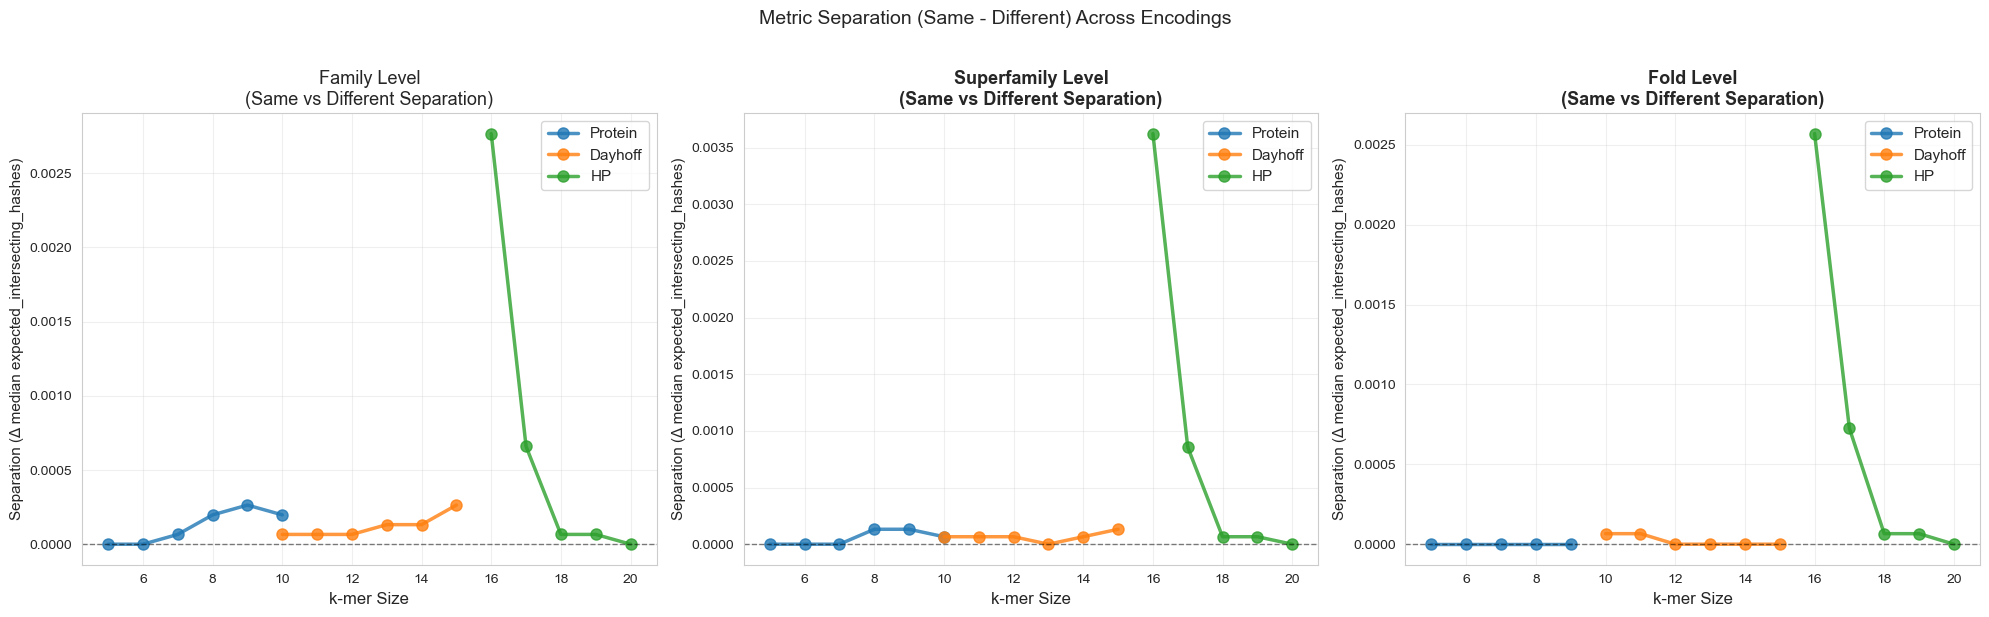


TOP 10 CONFIGURATIONS BY SEPARATION

SUPERFAMILY LEVEL:
  hp_k16                   : Δ=0.0036, ratio=1.26x, same=0.0174, diff=0.0138
  hp_k17                   : Δ=0.0009, ratio=1.18x, same=0.0056, diff=0.0047
  protein_k8               : Δ=0.0001, ratio=2.00x, same=0.0003, diff=0.0001
  protein_k9               : Δ=0.0001, ratio=2.00x, same=0.0003, diff=0.0001
  dayhoff_k15              : Δ=0.0001, ratio=2.00x, same=0.0003, diff=0.0001
  hp_k18                   : Δ=0.0001, ratio=1.04x, same=0.0016, diff=0.0015
  dayhoff_k12              : Δ=0.0001, ratio=1.50x, same=0.0002, diff=0.0001
  protein_k10              : Δ=0.0001, ratio=1.33x, same=0.0003, diff=0.0002
  dayhoff_k11              : Δ=0.0001, ratio=1.33x, same=0.0003, diff=0.0002
  dayhoff_k14              : Δ=0.0001, ratio=1.50x, same=0.0002, diff=0.0001

FOLD LEVEL:
  hp_k16                   : Δ=0.0026, ratio=1.19x, same=0.0163, diff=0.0138
  hp_k17                   : Δ=0.0007, ratio=1.15x, same=0.0055, diff=0.0047
  hp_k

In [24]:
# Plot 5: Statistical summary - Separation between same/different
# Calculate effect sizes (difference in medians) for each dataset

separation_data = []

for dataset_name, df in all_datasets.items():
    # Parse dataset info
    if "protein" in dataset_name:
        encoding = "Protein"
    elif "dayhoff" in dataset_name:
        encoding = "Dayhoff"
    elif "hp" in dataset_name:
        encoding = "HP"
    else:
        continue

    import re

    k_match = re.search(r"k(\d+)", dataset_name)
    k_size = int(k_match.group(1)) if k_match else None

    if best_metric_overall not in df.columns:
        continue

    # Calculate medians for each comparison
    for level_name, same_rel, diff_rel in [
        ("Family", "same_family", "different"),
        ("Superfamily", "same_superfamily", "different"),
        ("Fold", "same_fold", "different"),
    ]:
        same_vals = (
            df.filter(pl.col("relationship") == same_rel)
            .select(best_metric_overall)
            .to_series()
        )
        diff_vals = (
            df.filter(pl.col("relationship") == diff_rel)
            .select(best_metric_overall)
            .to_series()
        )

        if len(same_vals) > 0 and len(diff_vals) > 0:
            same_median = same_vals.median()
            diff_median = diff_vals.median()
            separation = same_median - diff_median
            ratio = same_median / diff_median if diff_median > 0 else 0

            separation_data.append(
                {
                    "dataset": dataset_name,
                    "encoding": encoding,
                    "k_size": k_size,
                    "level": level_name,
                    "separation": separation,
                    "ratio": ratio,
                    "same_median": same_median,
                    "diff_median": diff_median,
                }
            )

if separation_data:
    sep_df = pd.DataFrame(separation_data)

    # Plot separation by k-size for each level
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for idx, level in enumerate(["Family", "Superfamily", "Fold"]):
        ax = axes[idx]
        level_data = sep_df[sep_df["level"] == level]

        for encoding in ["Protein", "Dayhoff", "HP"]:
            enc_data = level_data[level_data["encoding"] == encoding].sort_values(
                "k_size"
            )
            if len(enc_data) > 0:
                ax.plot(
                    enc_data["k_size"],
                    enc_data["separation"],
                    marker="o",
                    markersize=8,
                    linewidth=2.5,
                    label=encoding,
                    alpha=0.8,
                )

        ax.set_xlabel("k-mer Size", fontsize=12)
        ax.set_ylabel(f"Separation (Δ median {best_metric_overall})", fontsize=11)
        ax.set_title(
            f"{level} Level\n(Same vs Different Separation)",
            fontsize=13,
            fontweight="bold" if level in ["Superfamily", "Fold"] else "normal",
        )
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

    plt.suptitle(
        f"Metric Separation (Same - Different) Across Encodings", fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.show()

    # Show best separations
    print("\n" + "=" * 100)
    print("TOP 10 CONFIGURATIONS BY SEPARATION")
    print("=" * 100)
    for level in ["Superfamily", "Fold"]:
        print(f"\n{level.upper()} LEVEL:")
        level_data = sep_df[sep_df["level"] == level].sort_values(
            "separation", ascending=False
        )
        for _, row in level_data.head(10).iterrows():
            print(
                f"  {row['dataset']:25s}: Δ={row['separation']:.4f}, "
                f"ratio={row['ratio']:.2f}x, same={row['same_median']:.4f}, diff={row['diff_median']:.4f}"
            )
else:
    print("No separation data calculated")

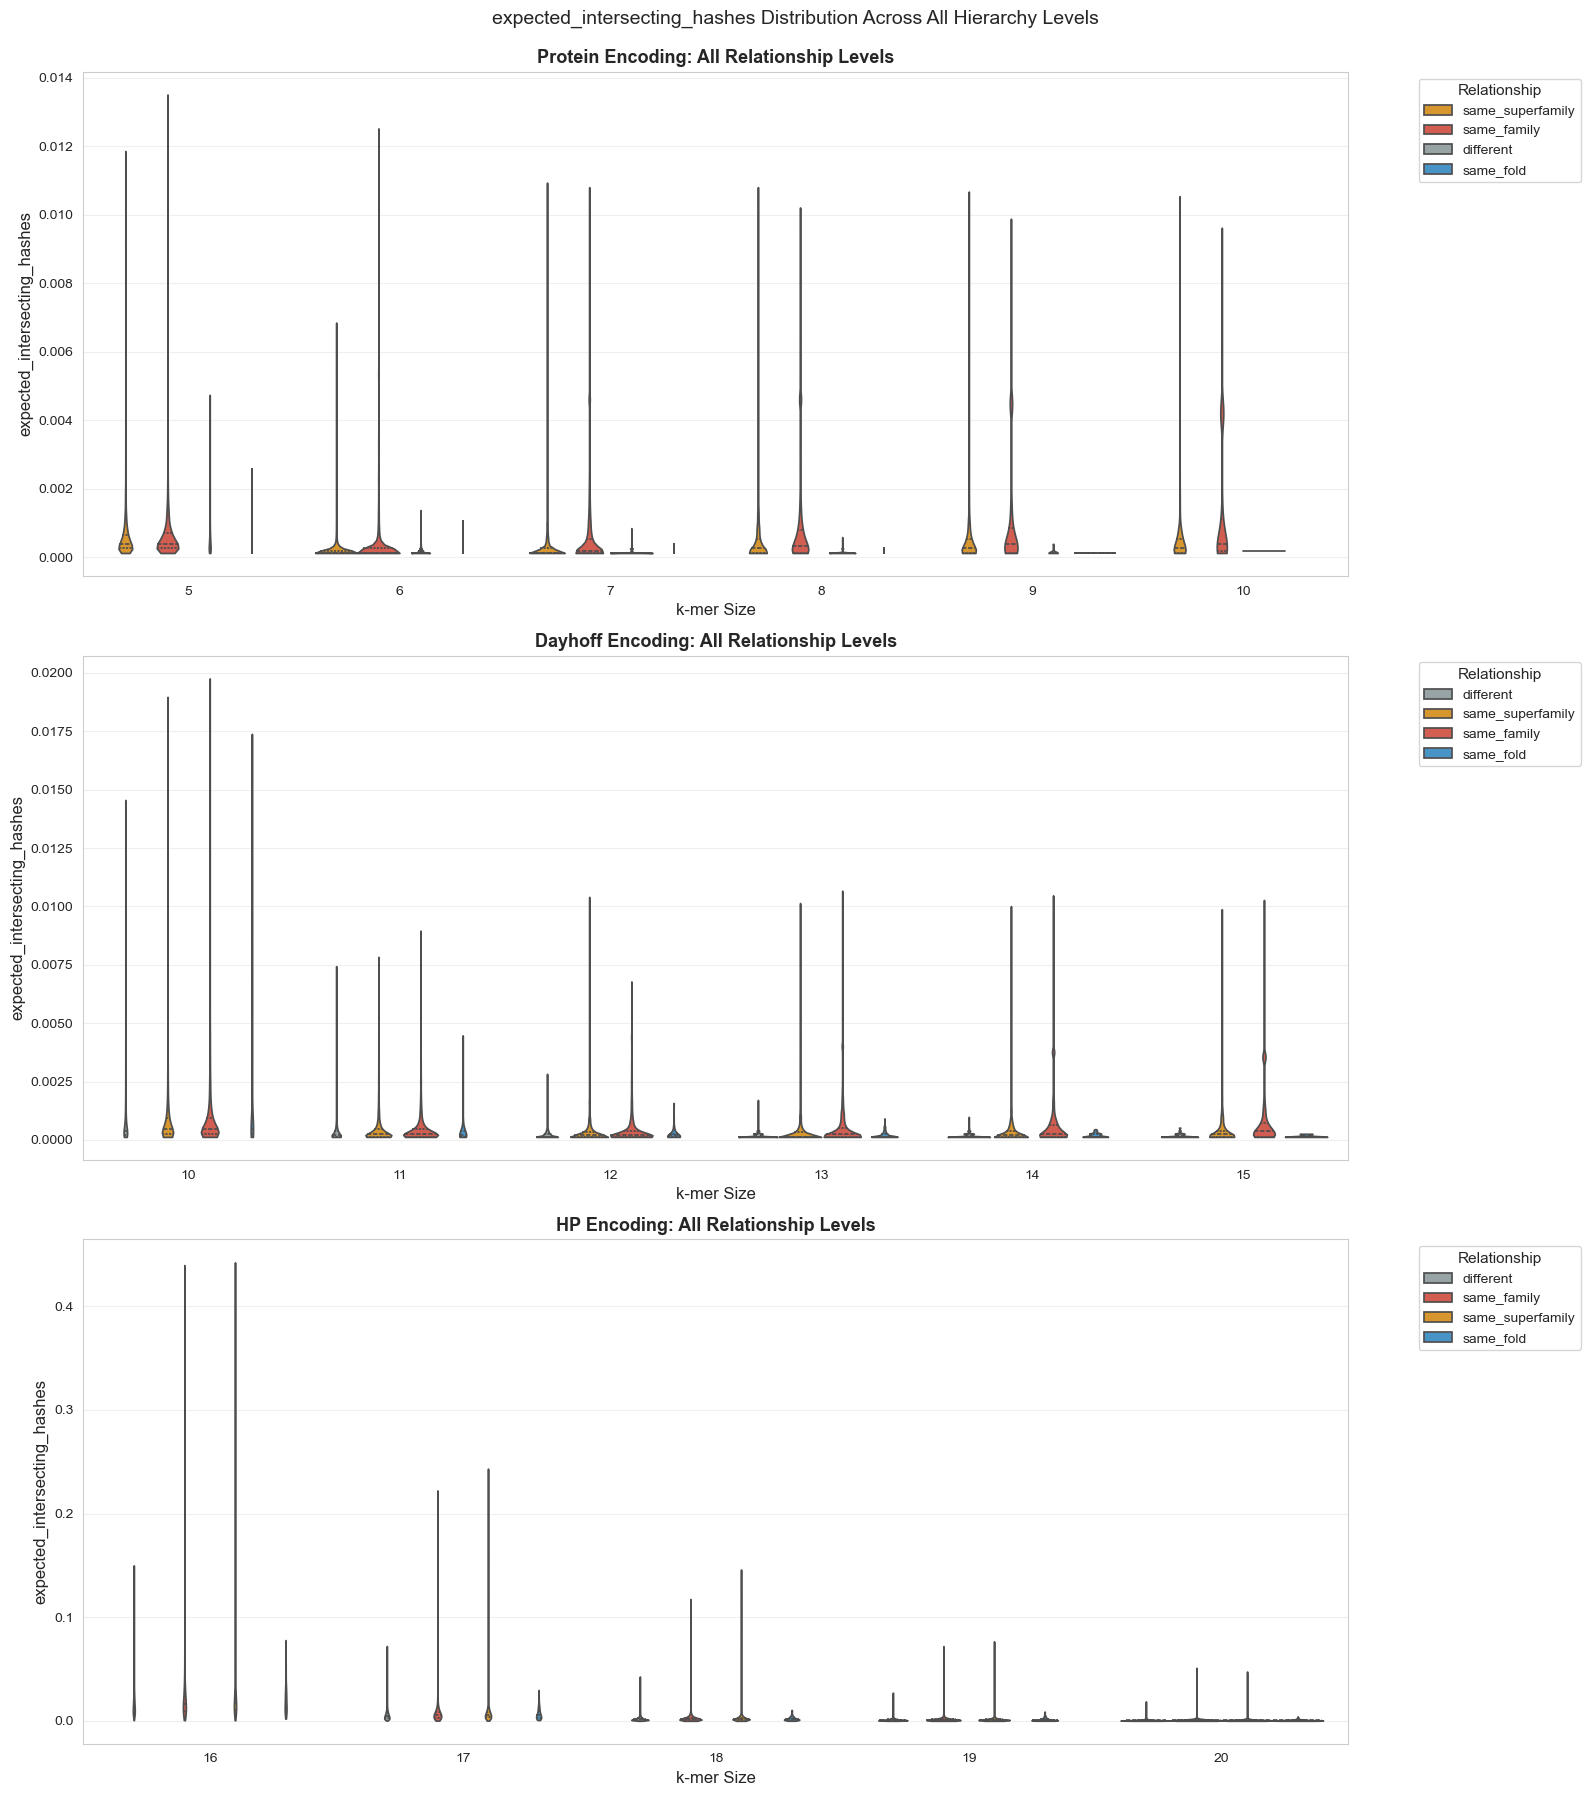

In [25]:
# Plot 4: Combined view - All relationships for each encoding
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

relationships_all = ["same_family", "same_superfamily", "same_fold", "different"]
palette_all = {
    "same_family": "#e74c3c",
    "same_superfamily": "#f39c12",
    "same_fold": "#3498db",
    "different": "#95a5a6",
}

for idx, encoding in enumerate(["Protein", "Dayhoff", "HP"]):
    ax = axes[idx]

    # Filter data for this encoding
    enc_data = combined_df[combined_df["encoding"] == encoding].copy()
    enc_data_filtered = enc_data[enc_data["relationship"].isin(relationships_all)]

    if len(enc_data_filtered) > 0:
        # Create violin plot with all relationships
        sns.violinplot(
            data=enc_data_filtered,
            x="k_size",
            y=best_metric_overall,
            hue="relationship",
            ax=ax,
            palette=palette_all,
            split=False,
            inner="quartile",
            cut=0,
        )

        ax.set_xlabel("k-mer Size", fontsize=12)
        ax.set_ylabel(best_metric_overall, fontsize=12)
        ax.set_title(
            f"{encoding} Encoding: All Relationship Levels",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(
            title="Relationship",
            fontsize=10,
            title_fontsize=11,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"{best_metric_overall} Distribution Across All Hierarchy Levels",
    fontsize=14,
    y=0.995,
)
plt.tight_layout()
plt.show()

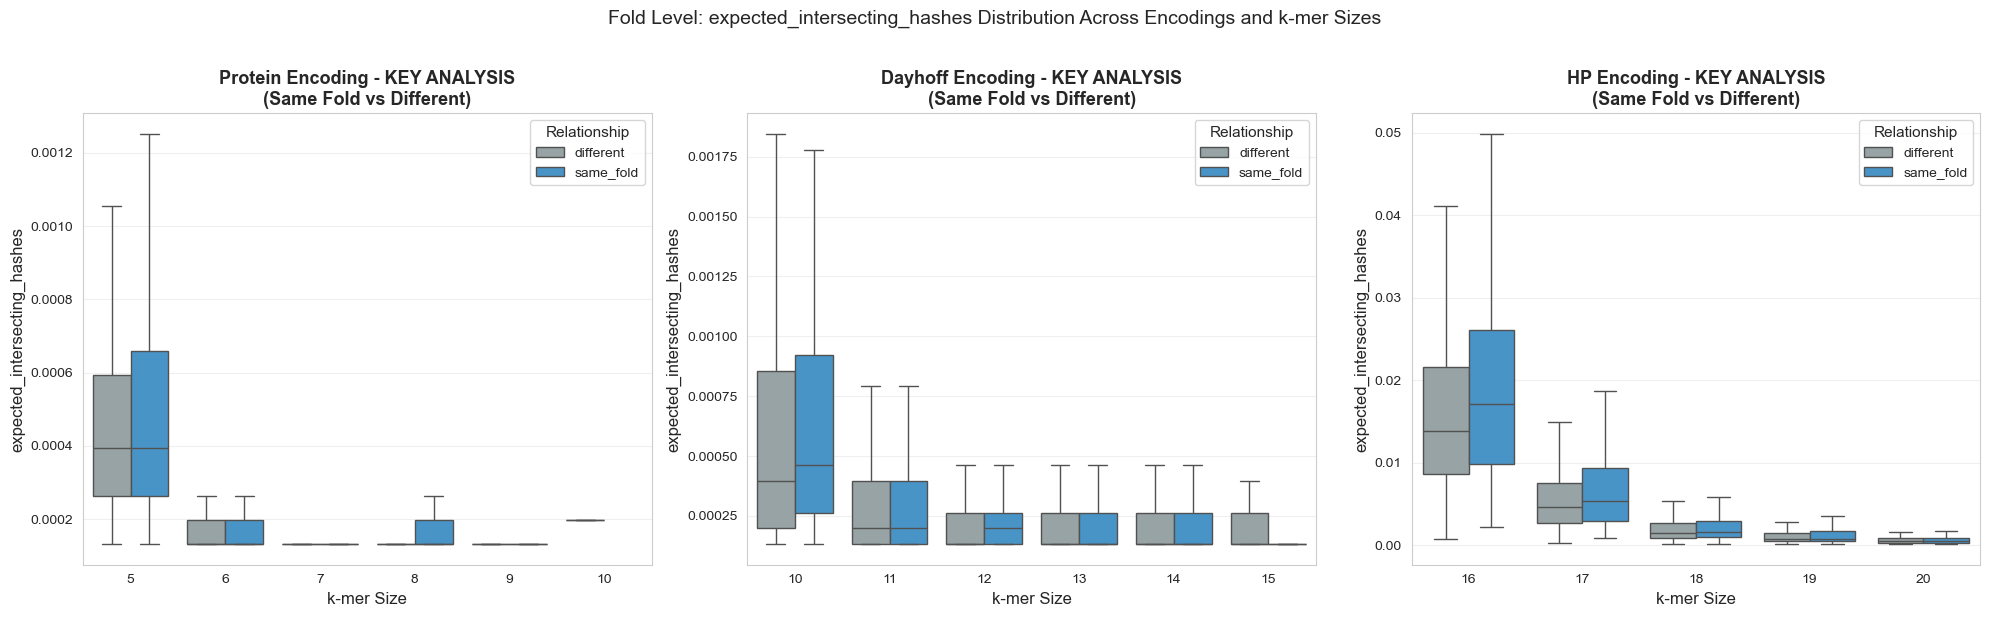

In [26]:
# Plot 3: Same-Fold vs Different-Fold across all datasets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, encoding in enumerate(["Protein", "Dayhoff", "HP"]):
    ax = axes[idx]

    # Filter data for this encoding
    enc_data = combined_df[combined_df["encoding"] == encoding].copy()

    # Filter to fold comparison
    enc_data_fold = enc_data[enc_data["relationship"].isin(["same_fold", "different"])]

    if len(enc_data_fold) > 0:
        # Create boxplot
        sns.boxplot(
            data=enc_data_fold,
            x="k_size",
            y=best_metric_overall,
            hue="relationship",
            ax=ax,
            palette={"same_fold": "#3498db", "different": "#95a5a6"},
            showfliers=False,
        )

        ax.set_xlabel("k-mer Size", fontsize=12)
        ax.set_ylabel(best_metric_overall, fontsize=12)
        ax.set_title(
            f"{encoding} Encoding - KEY ANALYSIS\n(Same Fold vs Different)",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(title="Relationship", fontsize=10, title_fontsize=11)
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Fold Level: {best_metric_overall} Distribution Across Encodings and k-mer Sizes",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

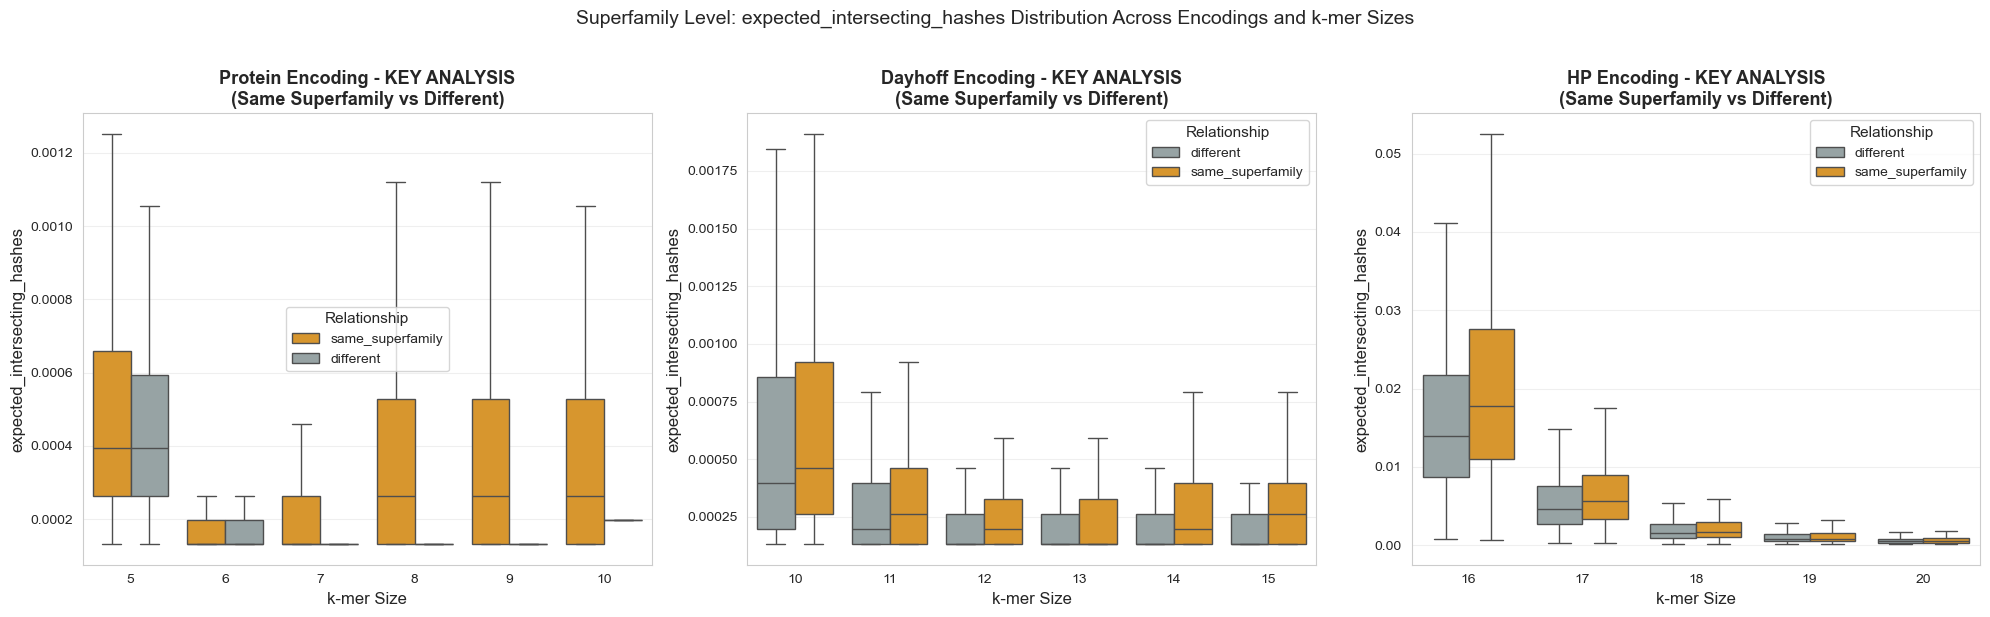

In [27]:
# Plot 2: Within-Superfamily vs Different-Superfamily across all datasets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, encoding in enumerate(["Protein", "Dayhoff", "HP"]):
    ax = axes[idx]

    # Filter data for this encoding
    enc_data = combined_df[combined_df["encoding"] == encoding].copy()

    # Filter to superfamily comparison
    enc_data_super = enc_data[
        enc_data["relationship"].isin(["same_superfamily", "different"])
    ]

    if len(enc_data_super) > 0:
        # Create boxplot
        sns.boxplot(
            data=enc_data_super,
            x="k_size",
            y=best_metric_overall,
            hue="relationship",
            ax=ax,
            palette={"same_superfamily": "#f39c12", "different": "#95a5a6"},
            showfliers=False,
        )

        ax.set_xlabel("k-mer Size", fontsize=12)
        ax.set_ylabel(best_metric_overall, fontsize=12)
        ax.set_title(
            f"{encoding} Encoding - KEY ANALYSIS\n(Same Superfamily vs Different)",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(title="Relationship", fontsize=10, title_fontsize=11)
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Superfamily Level: {best_metric_overall} Distribution Across Encodings and k-mer Sizes",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

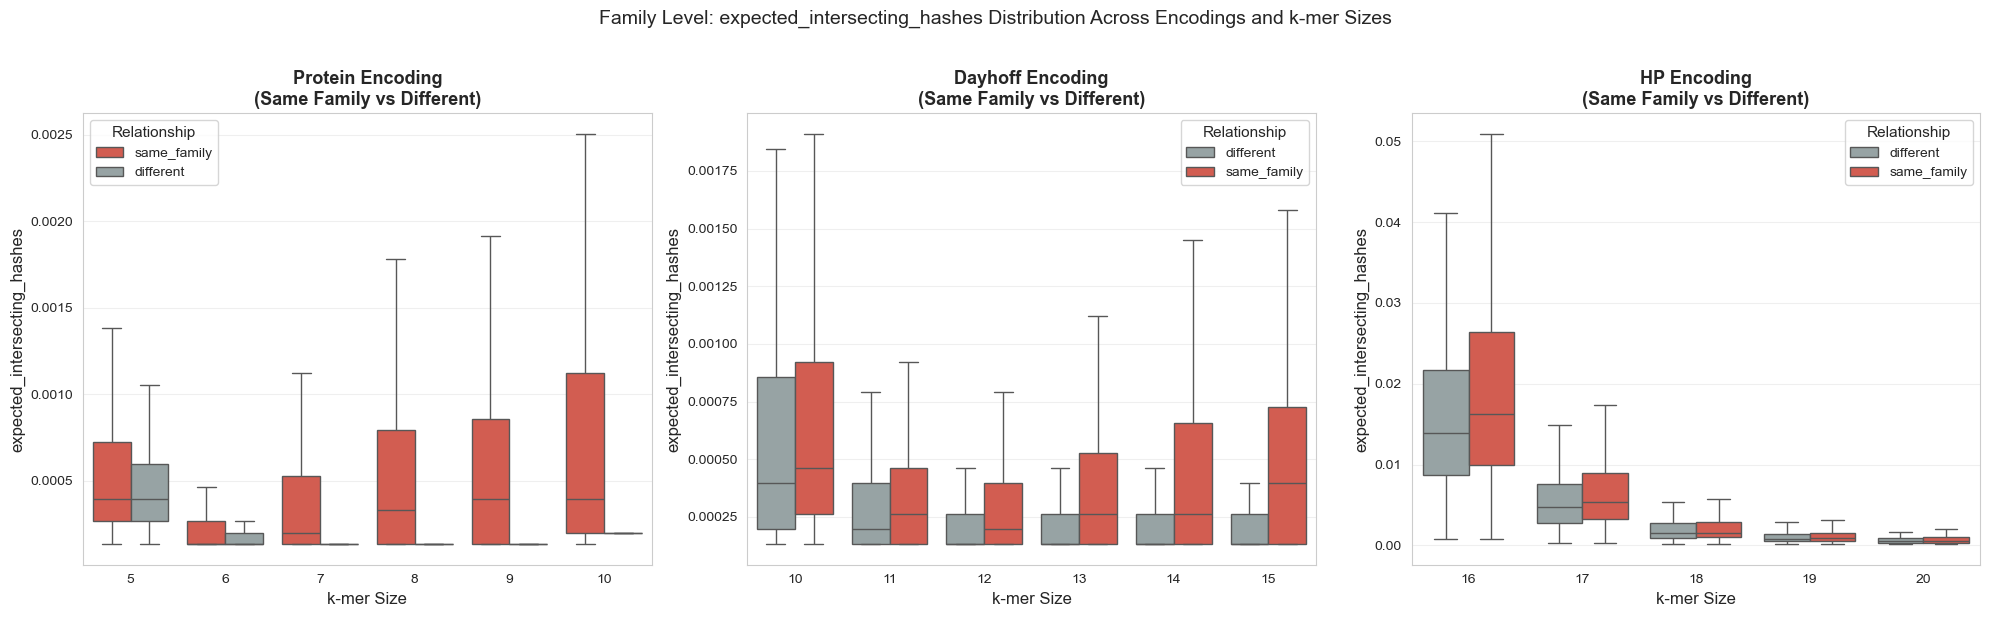

In [28]:
# Plot 1: Within-Family vs Different-Family across all datasets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, encoding in enumerate(["Protein", "Dayhoff", "HP"]):
    ax = axes[idx]

    # Filter data for this encoding
    enc_data = combined_df[combined_df["encoding"] == encoding].copy()

    # Filter to family comparison
    enc_data_family = enc_data[
        enc_data["relationship"].isin(["same_family", "different"])
    ]

    if len(enc_data_family) > 0:
        # Create catplot data
        sns.boxplot(
            data=enc_data_family,
            x="k_size",
            y=best_metric_overall,
            hue="relationship",
            ax=ax,
            palette={"same_family": "#e74c3c", "different": "#95a5a6"},
            showfliers=False,
        )

        ax.set_xlabel("k-mer Size", fontsize=12)
        ax.set_ylabel(best_metric_overall, fontsize=12)
        ax.set_title(
            f"{encoding} Encoding\n(Same Family vs Different)",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(title="Relationship", fontsize=10, title_fontsize=11)
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Family Level: {best_metric_overall} Distribution Across Encodings and k-mer Sizes",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

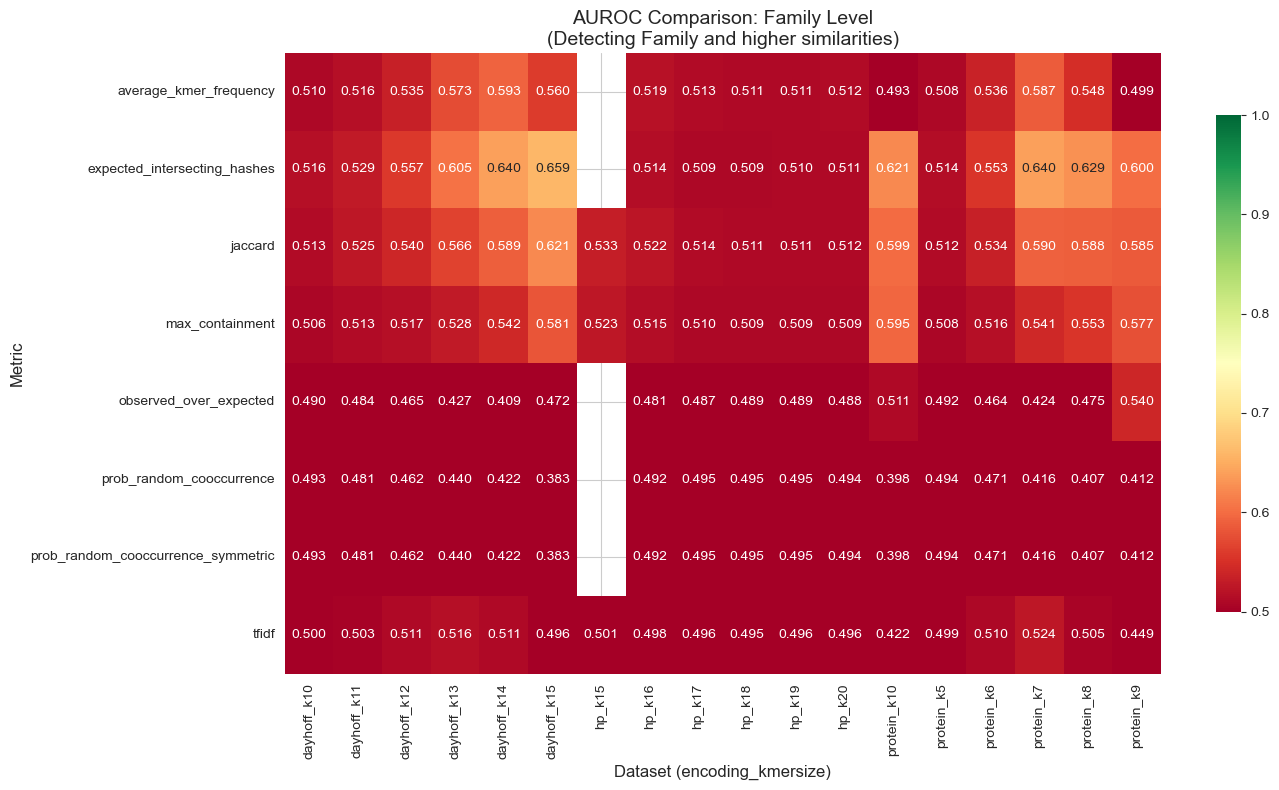


Family Level - Best metric per dataset:
  dayhoff_k10         : expected_intersecting_hashes        (AUROC=0.5157)
  dayhoff_k11         : expected_intersecting_hashes        (AUROC=0.5287)
  dayhoff_k12         : expected_intersecting_hashes        (AUROC=0.5566)
  dayhoff_k13         : expected_intersecting_hashes        (AUROC=0.6053)
  dayhoff_k14         : expected_intersecting_hashes        (AUROC=0.6398)
  dayhoff_k15         : expected_intersecting_hashes        (AUROC=0.6588)
  hp_k15              : jaccard                             (AUROC=0.5332)
  hp_k16              : jaccard                             (AUROC=0.5216)
  hp_k17              : jaccard                             (AUROC=0.5135)
  hp_k18              : average_kmer_frequency              (AUROC=0.5110)
  hp_k19              : average_kmer_frequency              (AUROC=0.5112)
  hp_k20              : average_kmer_frequency              (AUROC=0.5119)
  protein_k10         : expected_intersecting_hashes       

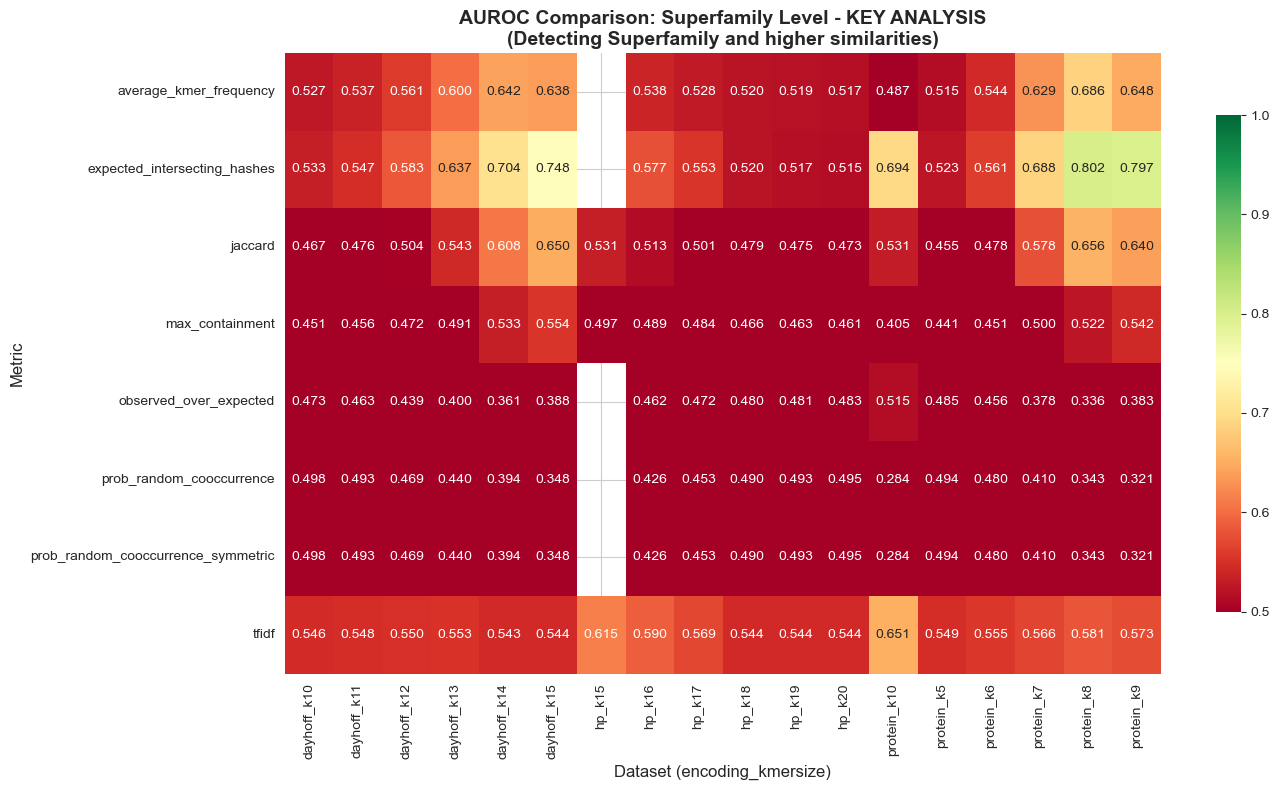


Superfamily Level - Best metric per dataset:
  dayhoff_k10         : tfidf                               (AUROC=0.5465)
  dayhoff_k11         : tfidf                               (AUROC=0.5479)
  dayhoff_k12         : expected_intersecting_hashes        (AUROC=0.5826)
  dayhoff_k13         : expected_intersecting_hashes        (AUROC=0.6369)
  dayhoff_k14         : expected_intersecting_hashes        (AUROC=0.7041)
  dayhoff_k15         : expected_intersecting_hashes        (AUROC=0.7478)
  hp_k15              : tfidf                               (AUROC=0.6146)
  hp_k16              : tfidf                               (AUROC=0.5897)
  hp_k17              : tfidf                               (AUROC=0.5691)
  hp_k18              : tfidf                               (AUROC=0.5440)
  hp_k19              : tfidf                               (AUROC=0.5439)
  hp_k20              : tfidf                               (AUROC=0.5439)
  protein_k10         : expected_intersecting_hashes  

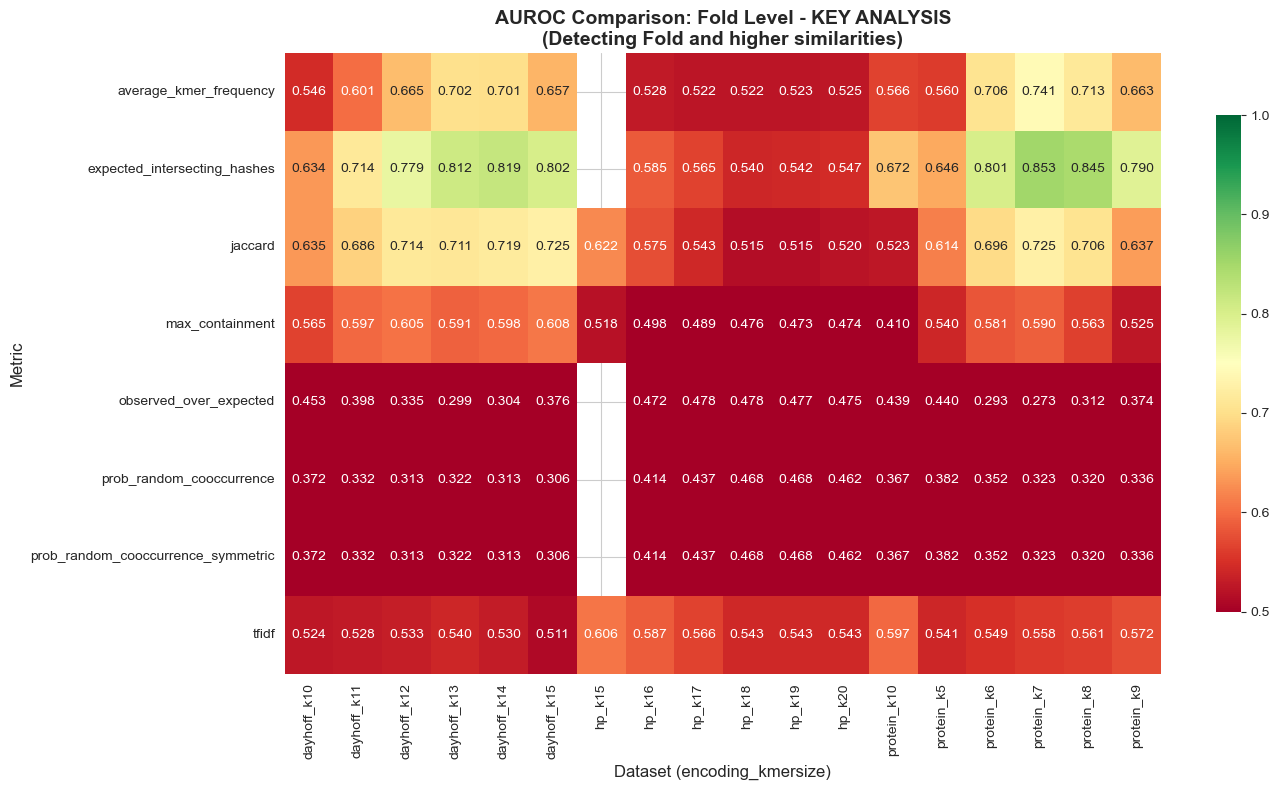


Fold Level - Best metric per dataset:
  dayhoff_k10         : jaccard                             (AUROC=0.6347)
  dayhoff_k11         : expected_intersecting_hashes        (AUROC=0.7139)
  dayhoff_k12         : expected_intersecting_hashes        (AUROC=0.7790)
  dayhoff_k13         : expected_intersecting_hashes        (AUROC=0.8123)
  dayhoff_k14         : expected_intersecting_hashes        (AUROC=0.8190)
  dayhoff_k15         : expected_intersecting_hashes        (AUROC=0.8017)
  hp_k15              : jaccard                             (AUROC=0.6218)
  hp_k16              : tfidf                               (AUROC=0.5866)
  hp_k17              : tfidf                               (AUROC=0.5663)
  hp_k18              : tfidf                               (AUROC=0.5428)
  hp_k19              : tfidf                               (AUROC=0.5428)
  hp_k20              : expected_intersecting_hashes        (AUROC=0.5468)
  protein_k10         : expected_intersecting_hashes        (

In [29]:
# Create heatmaps for each hierarchy level
for level in ["Family", "Superfamily", "Fold"]:
    level_data = all_results_df[all_results_df["hierarchy"] == level]

    if len(level_data) > 0:
        pivot_df = level_data.pivot(index="metric", columns="dataset", values="auroc")

        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(
            pivot_df,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            vmin=0.5,
            vmax=1.0,
            center=0.75,
            square=False,
            ax=ax,
            cbar_kws={"shrink": 0.8},
        )

        emphasis = " - KEY ANALYSIS" if level in ["Superfamily", "Fold"] else ""
        ax.set_title(
            f"AUROC Comparison: {level} Level{emphasis}\n(Detecting {level} and higher similarities)",
            fontsize=14,
            fontweight="bold" if level in ["Superfamily", "Fold"] else "normal",
        )
        ax.set_xlabel("Dataset (encoding_kmersize)", fontsize=12)
        ax.set_ylabel("Metric", fontsize=12)
        plt.tight_layout()
        plt.show()

        # Show best performing combinations
        print(f"\n{level} Level - Best metric per dataset:")
        for dataset in pivot_df.columns:
            best_metric = pivot_df[dataset].idxmax()
            best_auroc = pivot_df[dataset].max()
            print(f"  {dataset:20s}: {best_metric:35s} (AUROC={best_auroc:.4f})")

        print(f"\n{level} Level - Best dataset per metric:")
        for metric in pivot_df.index:
            best_dataset = pivot_df.loc[metric].idxmax()
            best_auroc = pivot_df.loc[metric].max()
            print(f"  {metric:35s}: {best_dataset:20s} (AUROC={best_auroc:.4f})")

In [30]:
# Overall performance comparison across encodings
# Group datasets by encoding type
encoding_performance = []

for dataset_name, df in all_datasets.items():
    # Determine encoding type
    if "protein" in dataset_name:
        encoding = "protein"
    elif "dayhoff" in dataset_name:
        encoding = "dayhoff"
    elif "hp" in dataset_name:
        encoding = "hp"
    else:
        encoding = "unknown"

    # Extract k-mer size
    import re

    k_match = re.search(r"k(\d+)", dataset_name)
    k_size = int(k_match.group(1)) if k_match else None

    # Calculate best AUROC for each hierarchy level - BINARY classification
    for level_name, positive_col in [
        ("Family", "same_family"),
        ("Superfamily", "same_superfamily"),
        ("Fold", "same_fold"),
    ]:
        best_auroc = 0
        best_metric = None

        for metric in metrics:
            if metric in df.columns:
                auroc, _, _ = calculate_auroc_for_metric(df, metric, positive_col)
                if auroc and auroc > best_auroc:
                    best_auroc = auroc
                    best_metric = metric

        if best_metric:
            encoding_performance.append(
                {
                    "dataset": dataset_name,
                    "encoding": encoding,
                    "k_size": k_size,
                    "hierarchy": level_name,
                    "best_metric": best_metric,
                    "best_auroc": best_auroc,
                }
            )

encoding_perf_df = pd.DataFrame(encoding_performance)
encoding_perf_df

,dataset,encoding,k_size,hierarchy,best_metric,best_auroc
0,protein_k5,protein,5,Family,expected_intersecting_hashes,0.513853
1,protein_k5,protein,5,Superfamily,tfidf,0.548690
2,protein_k5,protein,5,Fold,expected_intersecting_hashes,0.646487
3,protein_k6,protein,6,Family,expected_intersecting_hashes,0.553437
4,protein_k6,protein,6,Superfamily,expected_intersecting_hashes,0.560773
5,protein_k6,protein,6,Fold,expected_intersecting_hashes,0.801213
6,protein_k7,protein,7,Family,expected_intersecting_hashes,0.640185
7,protein_k7,protein,7,Superfamily,expected_intersecting_hashes,0.687546
8,protein_k7,protein,7,Fold,expected_intersecting_hashes,0.853014
9,protein_k8,protein,8,Family,expected_intersecting_hashes,0.628780


In [31]:
encoding_perf_df.sort_values("best_auroc", ascending=False).groupby("encoding").head()

,dataset,encoding,k_size,hierarchy,best_metric,best_auroc
8,protein_k7,protein,7,Fold,expected_intersecting_hashes,0.853014
11,protein_k8,protein,8,Fold,expected_intersecting_hashes,0.845255
32,dayhoff_k14,dayhoff,14,Fold,expected_intersecting_hashes,0.818985
29,dayhoff_k13,dayhoff,13,Fold,expected_intersecting_hashes,0.812334
10,protein_k8,protein,8,Superfamily,expected_intersecting_hashes,0.802367
35,dayhoff_k15,dayhoff,15,Fold,expected_intersecting_hashes,0.801701
5,protein_k6,protein,6,Fold,expected_intersecting_hashes,0.801213
13,protein_k9,protein,9,Superfamily,expected_intersecting_hashes,0.796982
26,dayhoff_k12,dayhoff,12,Fold,expected_intersecting_hashes,0.778988
34,dayhoff_k15,dayhoff,15,Superfamily,expected_intersecting_hashes,0.747763


In [32]:
encoding_perf_df.sort_values("best_auroc", ascending=False).groupby("hierarchy").head()

,dataset,encoding,k_size,hierarchy,best_metric,best_auroc
8,protein_k7,protein,7,Fold,expected_intersecting_hashes,0.853014
11,protein_k8,protein,8,Fold,expected_intersecting_hashes,0.845255
32,dayhoff_k14,dayhoff,14,Fold,expected_intersecting_hashes,0.818985
29,dayhoff_k13,dayhoff,13,Fold,expected_intersecting_hashes,0.812334
10,protein_k8,protein,8,Superfamily,expected_intersecting_hashes,0.802367
35,dayhoff_k15,dayhoff,15,Fold,expected_intersecting_hashes,0.801701
13,protein_k9,protein,9,Superfamily,expected_intersecting_hashes,0.796982
34,dayhoff_k15,dayhoff,15,Superfamily,expected_intersecting_hashes,0.747763
31,dayhoff_k14,dayhoff,14,Superfamily,expected_intersecting_hashes,0.704115
16,protein_k10,protein,10,Superfamily,expected_intersecting_hashes,0.693696


In [33]:
encoding_perf_df.sort_values("best_auroc", ascending=False).head()

,dataset,encoding,k_size,hierarchy,best_metric,best_auroc
8,protein_k7,protein,7,Fold,expected_intersecting_hashes,0.853014
11,protein_k8,protein,8,Fold,expected_intersecting_hashes,0.845255
32,dayhoff_k14,dayhoff,14,Fold,expected_intersecting_hashes,0.818985
29,dayhoff_k13,dayhoff,13,Fold,expected_intersecting_hashes,0.812334
10,protein_k8,protein,8,Superfamily,expected_intersecting_hashes,0.802367


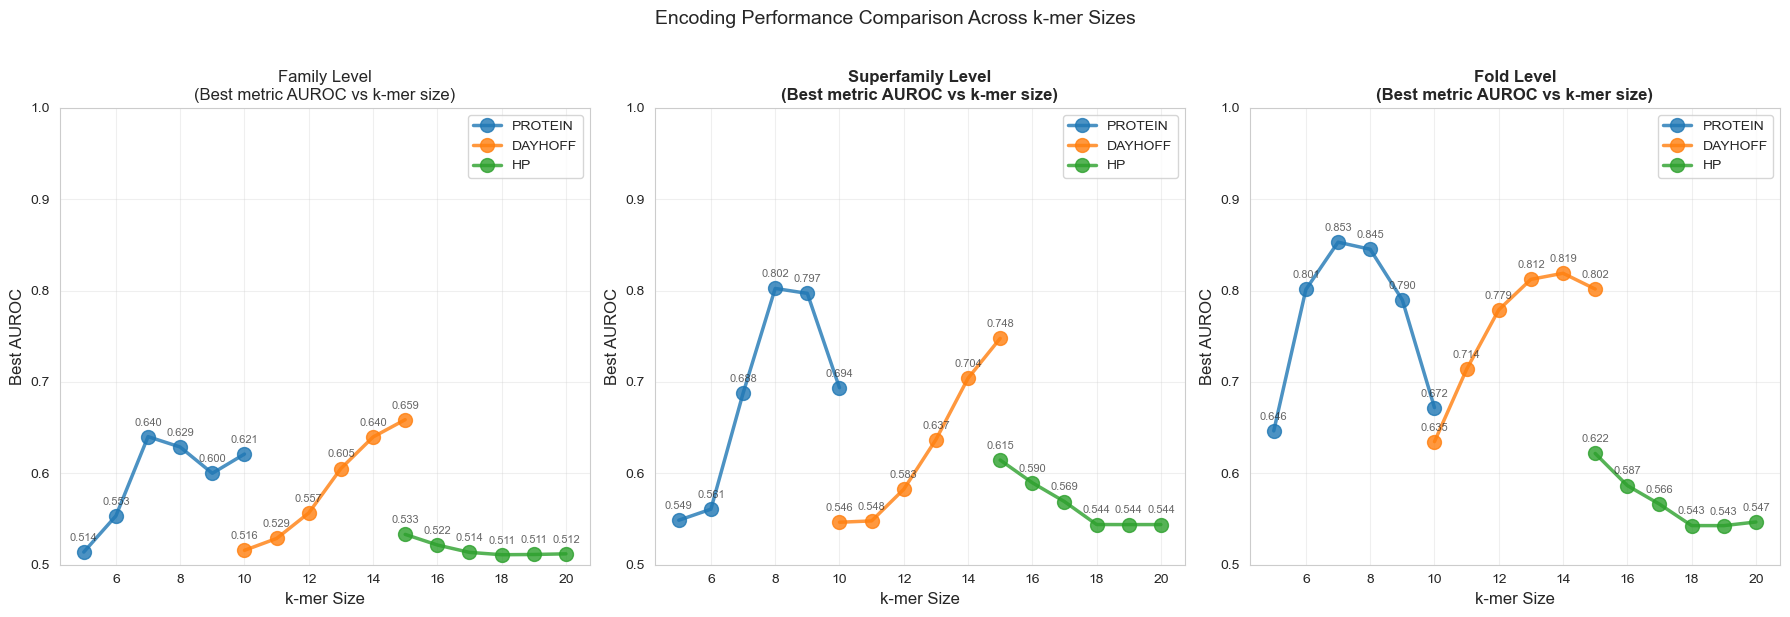

In [34]:
# Visualize encoding performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, level in enumerate(["Family", "Superfamily", "Fold"]):
    ax = axes[idx]
    level_data = encoding_perf_df[encoding_perf_df["hierarchy"] == level]

    # Group by encoding and plot
    for encoding in ["protein", "dayhoff", "hp"]:
        enc_data = level_data[level_data["encoding"] == encoding].sort_values("k_size")
        if len(enc_data) > 0:
            ax.plot(
                enc_data["k_size"],
                enc_data["best_auroc"],
                marker="o",
                markersize=10,
                linewidth=2.5,
                label=encoding.upper(),
                alpha=0.8,
            )

            # Annotate points
            for _, row in enc_data.iterrows():
                ax.annotate(
                    f"{row['best_auroc']:.3f}",
                    xy=(row["k_size"], row["best_auroc"]),
                    xytext=(0, 8),
                    textcoords="offset points",
                    fontsize=8,
                    ha="center",
                    alpha=0.7,
                )

    ax.set_xlabel("k-mer Size", fontsize=12)
    ax.set_ylabel("Best AUROC", fontsize=12)
    ax.set_title(
        f"{level} Level\n(Best metric AUROC vs k-mer size)",
        fontsize=12,
        fontweight="bold" if level in ["Superfamily", "Fold"] else "normal",
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.5, 1.0])

plt.suptitle("Encoding Performance Comparison Across k-mer Sizes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# Print final summary
print("=" * 100)
print("FINAL SUMMARY: BEST PERFORMING CONFIGURATIONS")
print("=" * 100)

for level in ["Family", "Superfamily", "Fold"]:
    print(f"\n{level.upper()} LEVEL:")
    level_data = encoding_perf_df[encoding_perf_df["hierarchy"] == level].sort_values(
        "best_auroc", ascending=False
    )

    print(f"\nTop 5 configurations:")
    for idx, (_, row) in enumerate(level_data.head(5).iterrows(), 1):
        print(
            f"  {idx}. {row['dataset']:25s} - {row['best_metric']:35s} AUROC={row['best_auroc']:.4f}"
        )

    print(f"\nBest by encoding:")
    for encoding in ["protein", "dayhoff", "hp"]:
        enc_best = level_data[level_data["encoding"] == encoding].head(1)
        if len(enc_best) > 0:
            row = enc_best.iloc[0]
            print(
                f"  {encoding.upper():10s}: {row['dataset']:25s} - {row['best_metric']:35s} AUROC={row['best_auroc']:.4f}"
            )

FINAL SUMMARY: BEST PERFORMING CONFIGURATIONS

FAMILY LEVEL:

Top 5 configurations:
  1. dayhoff_k15               - expected_intersecting_hashes        AUROC=0.6588
  2. protein_k7                - expected_intersecting_hashes        AUROC=0.6402
  3. dayhoff_k14               - expected_intersecting_hashes        AUROC=0.6398
  4. protein_k8                - expected_intersecting_hashes        AUROC=0.6288
  5. protein_k10               - expected_intersecting_hashes        AUROC=0.6211

Best by encoding:
  PROTEIN   : protein_k7                - expected_intersecting_hashes        AUROC=0.6402
  DAYHOFF   : dayhoff_k15               - expected_intersecting_hashes        AUROC=0.6588
  HP        : hp_k15                    - jaccard                             AUROC=0.5332

SUPERFAMILY LEVEL:

Top 5 configurations:
  1. protein_k8                - expected_intersecting_hashes        AUROC=0.8024
  2. protein_k9                - expected_intersecting_hashes        AUROC=0.7970
  3. da

In [36]:
# SENSITIVITY UNTIL FIRST FALSE POSITIVE
print("=" * 100)
print("SENSITIVITY UNTIL FIRST FALSE POSITIVE")
print("Binary classification for each level")
print("=" * 100)


def calculate_sensitivity_to_first_fp(df, metric_col, positive_relationships):
    """Calculate sensitivity (recall) until the first false positive

    This is a critical metric for remote homology detection:
    - How many true positives can we find before getting our first false positive?
    - More stringent than AUROC for high-precision applications

    Args:
        positive_relationships: Should be a single relationship for binary classification
    """
    # Create binary labels
    df_eval = df.with_columns(
        pl.col("relationship")
        .is_in(positive_relationships)
        .cast(pl.Int32)
        .alias("label")
    )

    # Filter out nulls
    df_eval = df_eval.filter(pl.col(metric_col).is_not_null())

    if df_eval.height == 0:
        return None, None, None

    # Convert to pandas and sort by metric (descending)
    pdf = df_eval.select([metric_col, "label"]).to_pandas()
    pdf = pdf.sort_values(metric_col, ascending=False)

    # Find first false positive
    cumsum_fp = (1 - pdf["label"]).cumsum()
    first_fp_idx = (cumsum_fp > 0).idxmax() if (cumsum_fp > 0).any() else len(pdf)

    # Calculate sensitivity at that point
    n_positives = pdf["label"].sum()
    if n_positives == 0:
        return 0.0, 0, 0

    n_tp_at_first_fp = pdf.loc[:first_fp_idx, "label"].sum()
    sensitivity_at_first_fp = n_tp_at_first_fp / n_positives

    return sensitivity_at_first_fp, n_tp_at_first_fp, n_positives


# Calculate for all datasets - BINARY classification
sensitivity_results = []

for dataset_name, df in all_datasets.items():
    print(f"Calculating sensitivity for {dataset_name}...")

    # Parse dataset info
    if "protein" in dataset_name:
        encoding = "Protein"
    elif "dayhoff" in dataset_name:
        encoding = "Dayhoff"
    elif "hp" in dataset_name:
        encoding = "HP"
    else:
        continue

    import re

    k_match = re.search(r"k(\d+)", dataset_name)
    k_size = int(k_match.group(1)) if k_match else None

    if best_metric_overall not in df.columns:
        continue

    # Calculate for superfamily and fold - BINARY classification
    for level_name, positive_col in [
        ("Superfamily", ["same_superfamily"]),
        ("Fold", ["same_fold"]),
    ]:
        sens, n_tp, n_pos = calculate_sensitivity_to_first_fp(
            df, best_metric_overall, positive_col
        )

        if sens is not None:
            sensitivity_results.append(
                {
                    "dataset": dataset_name,
                    "encoding": encoding,
                    "k_size": k_size,
                    "level": level_name,
                    "sensitivity_at_first_fp": sens,
                    "n_true_positives": n_tp,
                    "total_positives": n_pos,
                    "metric": best_metric_overall,
                }
            )

sensitivity_df = pd.DataFrame(sensitivity_results)
print(f"\nCalculated sensitivity for {len(sensitivity_df)} dataset-level combinations")

SENSITIVITY UNTIL FIRST FALSE POSITIVE
Binary classification for each level
Calculating sensitivity for protein_k5...
Calculating sensitivity for protein_k6...
Calculating sensitivity for protein_k7...
Calculating sensitivity for protein_k8...
Calculating sensitivity for protein_k9...
Calculating sensitivity for protein_k10...
Calculating sensitivity for dayhoff_k10...
Calculating sensitivity for dayhoff_k11...
Calculating sensitivity for dayhoff_k12...
Calculating sensitivity for dayhoff_k13...
Calculating sensitivity for dayhoff_k14...
Calculating sensitivity for dayhoff_k15...
Calculating sensitivity for hp_k15...
Calculating sensitivity for hp_k16...
Calculating sensitivity for hp_k17...
Calculating sensitivity for hp_k18...
Calculating sensitivity for hp_k19...
Calculating sensitivity for hp_k20...

Calculated sensitivity for 34 dataset-level combinations


COMPREHENSIVE SENSITIVITY UNTIL FIRST FP - ALL METRICS, ENCODINGS, K-SIZES

Calculating Family level curves...
  Family panel complete

Calculating Superfamily level curves...
  Superfamily panel complete

Calculating Fold level curves...
  Fold panel complete


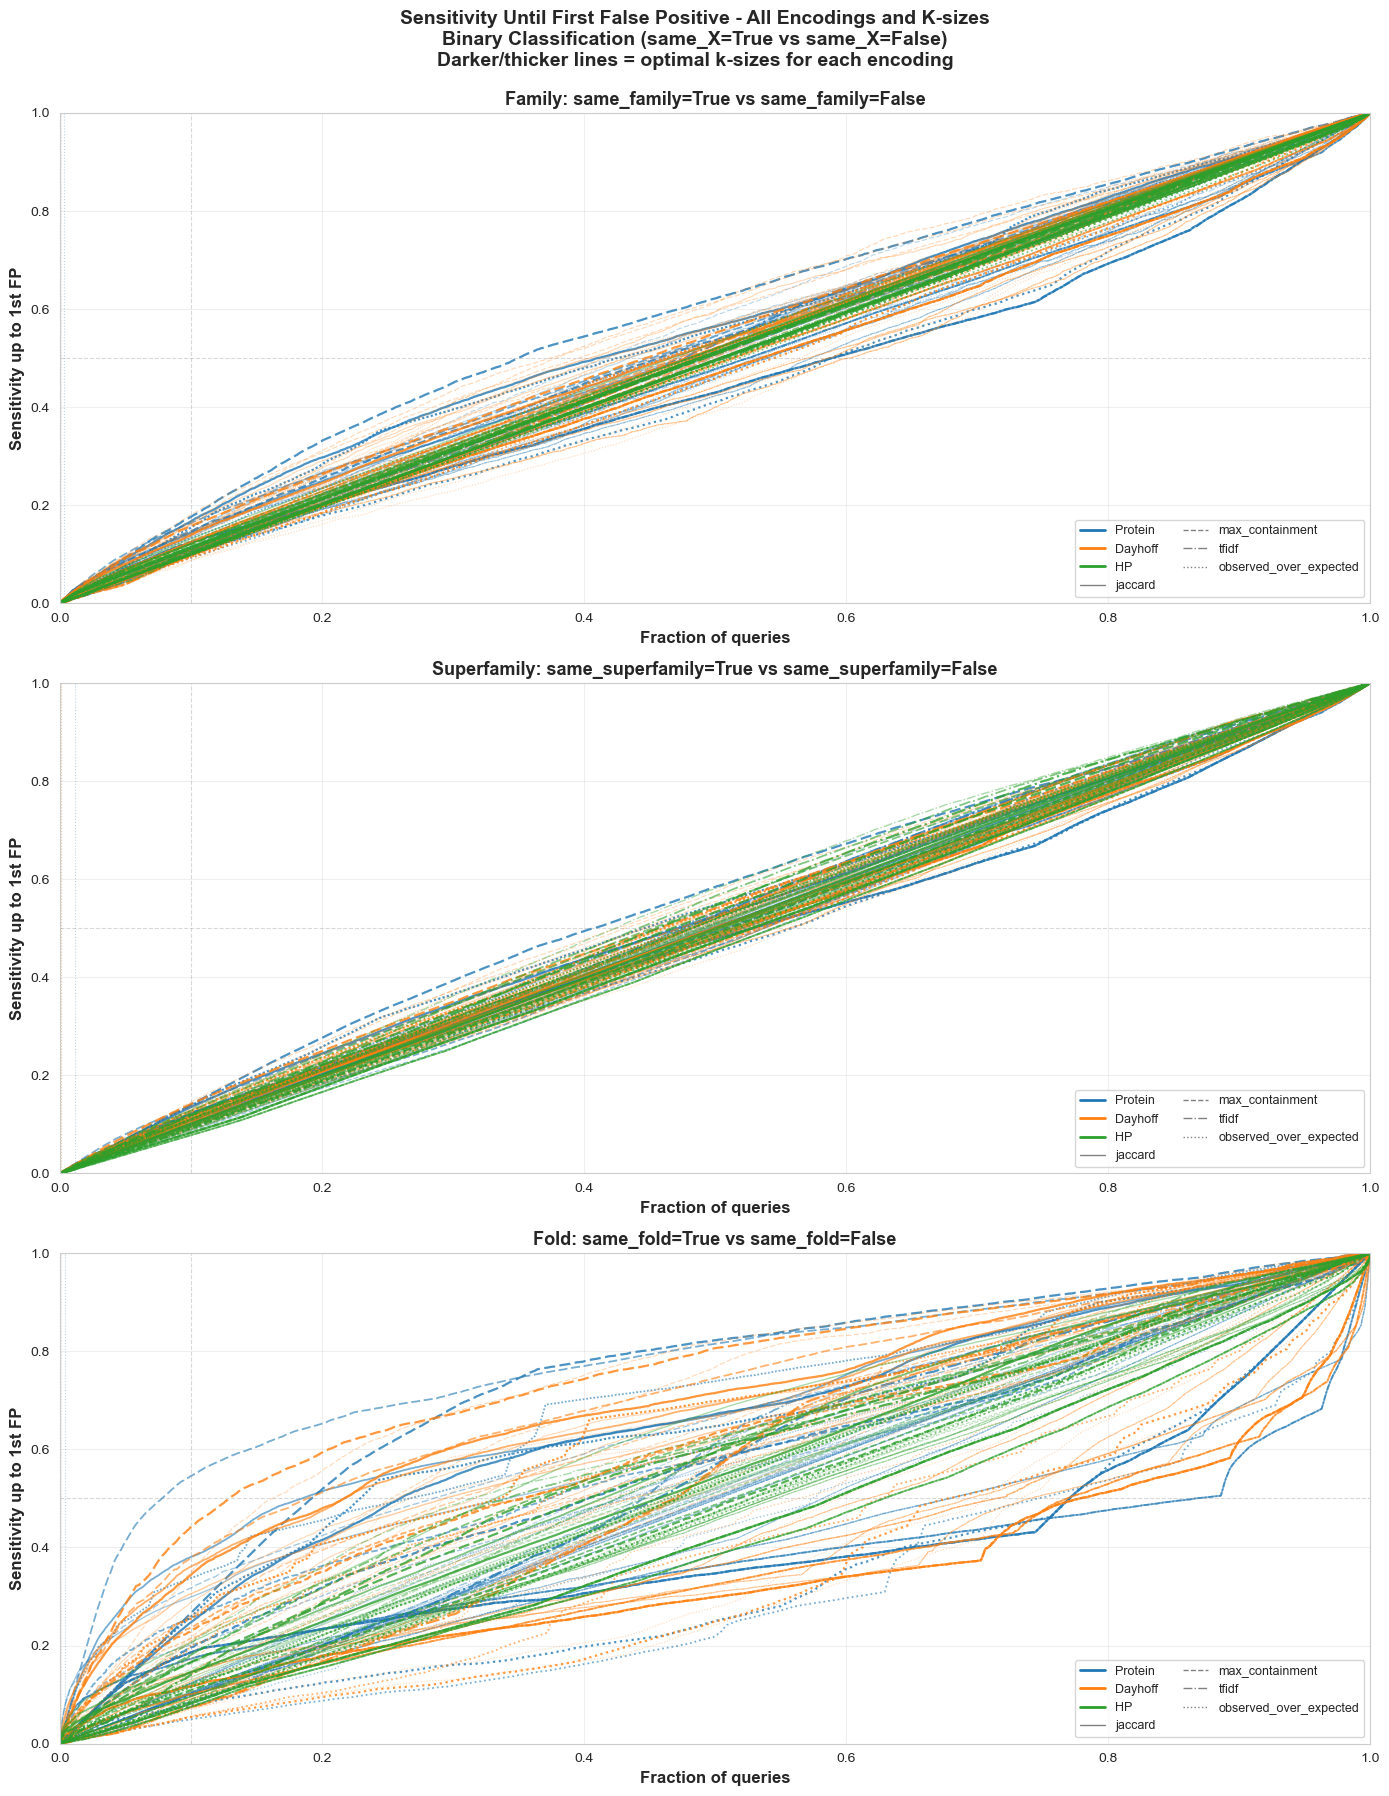


Plot complete!


In [37]:
# COMPREHENSIVE SENSITIVITY UNTIL FIRST FP PLOT
# Similar to the reference plot showing all metrics, encodings, and k-sizes
print("=" * 100)
print("COMPREHENSIVE SENSITIVITY UNTIL FIRST FP - ALL METRICS, ENCODINGS, K-SIZES")
print("=" * 100)


def calculate_sensitivity_curve_to_first_fp(df, metric_col, positive_col):
    """Calculate full sensitivity curve until first FP for binary classification

    Args:
        df: polars dataframe
        metric_col: metric to use for ranking
        positive_col: boolean column (same_family, same_superfamily, or same_fold)

    Returns:
        fractions: fraction of queries (x-axis)
        sensitivities: sensitivity values (y-axis)
        first_fp_frac: fraction of queries at first FP
        sensitivity_at_first_fp: sensitivity value at first FP
    """
    # Use boolean column directly
    df_eval = df.with_columns(pl.col(positive_col).cast(pl.Int32).alias("label"))

    # Filter out nulls
    df_eval = df_eval.filter(pl.col(metric_col).is_not_null())

    if df_eval.height == 0:
        return None, None, None, None

    # Convert to pandas and sort by metric (descending for ranking)
    pdf = df_eval.select([metric_col, "label"]).to_pandas()
    pdf = pdf.sort_values(metric_col, ascending=False).reset_index(drop=True)

    n_total = len(pdf)
    n_positives = pdf["label"].sum()

    if n_positives == 0:
        return None, None, None, None

    # Calculate cumulative true positives and false positives
    cumsum_tp = pdf["label"].cumsum()
    cumsum_fp = (1 - pdf["label"]).cumsum()

    # Calculate sensitivity at each point
    sensitivities = cumsum_tp / n_positives
    fractions = np.arange(1, n_total + 1) / n_total

    # Find first false positive
    first_fp_idx = (cumsum_fp > 0).idxmax() if (cumsum_fp > 0).any() else n_total - 1
    first_fp_frac = (first_fp_idx + 1) / n_total
    sensitivity_at_first_fp = sensitivities.iloc[first_fp_idx]

    return fractions, sensitivities.values, first_fp_frac, sensitivity_at_first_fp


# Create the multi-panel plot
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Panel A: Family level
# Panel B: Superfamily level
# Panel C: Fold level

levels = [
    ("Family", "same_family", axes[0]),
    ("Superfamily", "same_superfamily", axes[1]),
    ("Fold", "same_fold", axes[2]),
]

# Define colors for different encodings
encoding_colors = {
    "protein": "#1f77b4",  # blue
    "dayhoff": "#ff7f0e",  # orange
    "hp": "#2ca02c",  # green
}

# Line styles for different metrics
metric_styles = {
    "jaccard": "-",
    "max_containment": "--",
    "tfidf": "-.",
    "observed_over_expected": ":",
    "prob_random_cooccurrence": (0, (3, 1, 1, 1)),
    "expected_intersecting_hashes": (0, (5, 2)),
    "average_kmer_frequency": (0, (1, 1)),
}

for level_name, positive_col, ax in levels:
    print(f"\nCalculating {level_name} level curves...")

    # Track which combinations to include in legend
    legend_handles = []
    legend_labels = []

    # Process each dataset
    for dataset_name, df in all_datasets.items():
        # Parse encoding and k-size
        if "protein" in dataset_name:
            encoding = "protein"
        elif "dayhoff" in dataset_name:
            encoding = "dayhoff"
        elif "hp" in dataset_name:
            encoding = "hp"
        else:
            continue

        import re

        k_match = re.search(r"k(\d+)", dataset_name)
        k_size = int(k_match.group(1)) if k_match else None

        # For each metric available in this dataset
        for metric in metrics:
            if metric not in df.columns:
                continue

            # Calculate sensitivity curve
            fracs, sens, first_fp_frac, sens_at_fp = (
                calculate_sensitivity_curve_to_first_fp(df, metric, positive_col)
            )

            if fracs is None:
                continue

            # Plot the curve
            color = encoding_colors.get(encoding, "#333333")
            linestyle = metric_styles.get(metric, "-")

            # Vary alpha and linewidth by k-size (darker/thicker for optimal k)
            if encoding == "protein" and k_size in [5, 6, 7]:
                alpha = 0.4 + (k_size - 5) * 0.2  # 5=0.4, 6=0.6, 7=0.8
                linewidth = 1.0 + (k_size - 5) * 0.3
            elif encoding == "dayhoff" and k_size in [10, 11, 12]:
                alpha = 0.4 + (k_size - 10) * 0.2
                linewidth = 1.0 + (k_size - 10) * 0.3
            elif encoding == "hp" and k_size in [15, 16, 17]:
                alpha = 0.4 + (k_size - 15) * 0.2
                linewidth = 1.0 + (k_size - 15) * 0.3
            else:
                alpha = 0.3
                linewidth = 0.8

            (line,) = ax.plot(
                fracs,
                sens,
                color=color,
                linestyle=linestyle,
                alpha=alpha,
                linewidth=linewidth,
                label=f"{encoding} k{k_size} {metric}",
            )

            # Add vertical line at first FP for key metrics
            if metric in ["tfidf", "observed_over_expected"] and alpha > 0.6:
                ax.axvline(
                    first_fp_frac, color=color, linestyle=":", alpha=0.3, linewidth=0.8
                )

    # Format the subplot
    ax.set_xlabel("Fraction of queries", fontsize=12, fontweight="bold")
    ax.set_ylabel("Sensitivity up to 1st FP", fontsize=12, fontweight="bold")
    ax.set_title(
        f"{level_name}: {positive_col}=True vs {positive_col}=False",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    # Add reference lines
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.axvline(0.1, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)

    # Create custom legend for this panel
    # Show encoding colors and a few key metrics
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0], [0], color=encoding_colors["protein"], linewidth=2, label="Protein"
        ),
        Line2D(
            [0], [0], color=encoding_colors["dayhoff"], linewidth=2, label="Dayhoff"
        ),
        Line2D([0], [0], color=encoding_colors["hp"], linewidth=2, label="HP"),
        Line2D([0], [0], color="gray", linewidth=1, linestyle="-", label="jaccard"),
        Line2D(
            [0], [0], color="gray", linewidth=1, linestyle="--", label="max_containment"
        ),
        Line2D([0], [0], color="gray", linewidth=1, linestyle="-.", label="tfidf"),
        Line2D(
            [0],
            [0],
            color="gray",
            linewidth=1,
            linestyle=":",
            label="observed_over_expected",
        ),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9, ncol=2)

    print(f"  {level_name} panel complete")

plt.suptitle(
    "Sensitivity Until First False Positive - All Encodings and K-sizes\n"
    + "Binary Classification (same_X=True vs same_X=False)\n"
    + "Darker/thicker lines = optimal k-sizes for each encoding",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

print("\n" + "=" * 100)
print("Plot complete!")
print("=" * 100)

ROC CURVE COMPARISON - FOLD LEVEL
Binary: same_fold=True vs same_fold=False
Calculating ROC for protein_k5...
Calculating ROC for protein_k6...
Calculating ROC for protein_k7...
Calculating ROC for protein_k8...
Calculating ROC for protein_k9...
Calculating ROC for protein_k10...
Calculating ROC for dayhoff_k10...
Calculating ROC for dayhoff_k11...
Calculating ROC for dayhoff_k12...
Calculating ROC for dayhoff_k13...
Calculating ROC for dayhoff_k14...
Calculating ROC for dayhoff_k15...
Calculating ROC for hp_k15...
Calculating ROC for hp_k16...
Calculating ROC for hp_k17...
Calculating ROC for hp_k18...
Calculating ROC for hp_k19...
Calculating ROC for hp_k20...

Calculated ROC curves for 17 datasets


NameError: name 'cm' is not defined

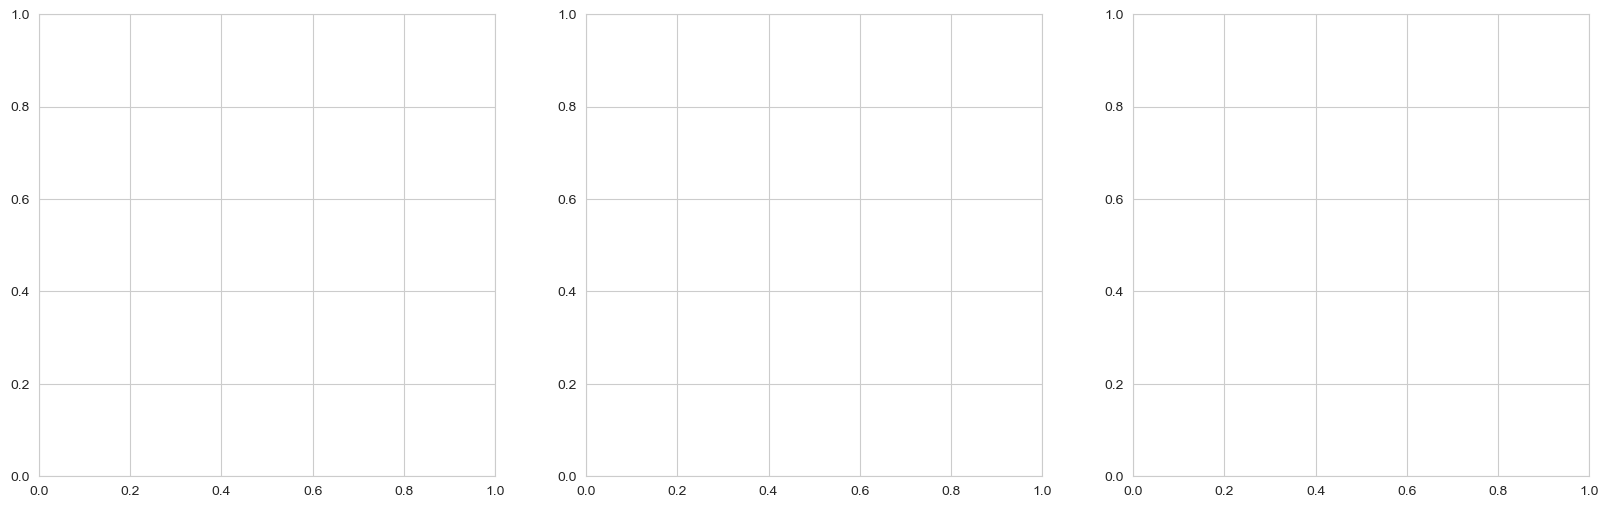

: 

In [ ]:
# ROC CURVES: Fold level
print("=" * 100)
print("ROC CURVE COMPARISON - FOLD LEVEL")
print("Binary: same_fold=True vs same_fold=False")
print("=" * 100)

roc_data_fold = {}

for dataset_name, df in all_datasets.items():
    print(f"Calculating ROC for {dataset_name}...")

    if best_metric_overall in df.columns:
        auroc, fpr, tpr = calculate_auroc_for_metric(
            df, best_metric_overall, "same_fold"
        )

        if auroc is not None:
            # Parse dataset info
            if "protein" in dataset_name:
                encoding = "Protein"
            elif "dayhoff" in dataset_name:
                encoding = "Dayhoff"
            elif "hp" in dataset_name:
                encoding = "HP"
            else:
                encoding = "Unknown"

            import re

            k_match = re.search(r"k(\d+)", dataset_name)
            k_size = int(k_match.group(1)) if k_match else None

            roc_data_fold[dataset_name] = {
                "auroc": auroc,
                "fpr": fpr,
                "tpr": tpr,
                "encoding": encoding,
                "k_size": k_size,
            }

print(f"\nCalculated ROC curves for {len(roc_data_fold)} datasets")

# Plot ROC curves for Fold level
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, encoding in enumerate(["Protein", "Dayhoff", "HP"]):
    ax = axes[idx]

    enc_datasets = {
        name: data
        for name, data in roc_data_fold.items()
        if data["encoding"] == encoding
    }

    if enc_datasets:
        sorted_datasets = sorted(enc_datasets.items(), key=lambda x: x[1]["k_size"])
        k_sizes = [data["k_size"] for _, data in sorted_datasets]
        cmap = cm.get_cmap("viridis")
        norm = mcolors.Normalize(vmin=min(k_sizes), vmax=max(k_sizes))

        for dataset_name, data in sorted_datasets:
            color = cmap(norm(data["k_size"]))
            ax.plot(
                data["fpr"],
                data["tpr"],
                label=f"k={data['k_size']} (AUC={data['auroc']:.3f})",
                linewidth=2.5,
                color=color,
                alpha=0.8,
            )

        ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1.5, alpha=0.5)

        ax.set_xlabel("False Positive Rate", fontsize=12)
        ax.set_ylabel("True Positive Rate", fontsize=12)
        ax.set_title(
            f"{encoding} Encoding - ROC Curves\n(Fold Detection - {best_metric_overall})",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-0.01, 1.01])
        ax.set_ylim([-0.01, 1.01])

plt.suptitle(
    "ROC Curves: Fold Detection (Binary: same_fold vs NOT same_fold)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
# DIAGNOSTIC: TF-IDF and Jaccard Sensitivity Curves
# Investigating why fold level performs so well
print("=" * 100)
print("DIAGNOSTIC: TF-IDF vs Jaccard - Sensitivity Until First FP")
print("Checking if fold level results are suspicious")
print("=" * 100)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

levels = [
    ("Family", "same_family", 0),
    ("Superfamily", "same_superfamily", 1),
    ("Fold", "same_fold", 2),
]

# Focus on just protein k=10 first for clarity
if "protein_k10" in all_datasets:
    df = all_datasets["protein_k10"]

    for level_name, positive_col, row_idx in levels:
        print(f"\nProcessing {level_name} level ({positive_col})...")

        # Left column: TF-IDF
        ax_tfidf = axes[row_idx, 0]

        # Right column: Jaccard
        ax_jaccard = axes[row_idx, 1]

        # Calculate curves for TF-IDF
        if "tfidf" in df.columns:
            fracs, sens, first_fp_frac, sens_at_fp = (
                calculate_sensitivity_curve_to_first_fp(df, "tfidf", positive_col)
            )

            if fracs is not None:
                ax_tfidf.plot(
                    fracs, sens, color="#e74c3c", linewidth=2.5, label="TF-IDF"
                )
                ax_tfidf.axvline(
                    first_fp_frac,
                    color="#e74c3c",
                    linestyle="--",
                    alpha=0.5,
                    linewidth=2,
                )
                ax_tfidf.axhline(
                    sens_at_fp, color="#e74c3c", linestyle=":", alpha=0.5, linewidth=1
                )

                # Annotate the first FP point
                ax_tfidf.scatter(
                    [first_fp_frac], [sens_at_fp], color="#e74c3c", s=100, zorder=5
                )
                ax_tfidf.annotate(
                    f"1st FP\nSens={sens_at_fp:.3f}\nFrac={first_fp_frac:.4f}",
                    xy=(first_fp_frac, sens_at_fp),
                    xytext=(first_fp_frac + 0.1, sens_at_fp - 0.1),
                    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
                    fontsize=9,
                    arrowprops=dict(arrowstyle="->", color="red"),
                )

                print(
                    f"  TF-IDF: Sensitivity at 1st FP = {sens_at_fp:.4f}, Fraction = {first_fp_frac:.6f}"
                )

        # Calculate curves for Jaccard
        if "jaccard" in df.columns:
            fracs, sens, first_fp_frac, sens_at_fp = (
                calculate_sensitivity_curve_to_first_fp(df, "jaccard", positive_col)
            )

            if fracs is not None:
                ax_jaccard.plot(
                    fracs, sens, color="#3498db", linewidth=2.5, label="Jaccard"
                )
                ax_jaccard.axvline(
                    first_fp_frac,
                    color="#3498db",
                    linestyle="--",
                    alpha=0.5,
                    linewidth=2,
                )
                ax_jaccard.axhline(
                    sens_at_fp, color="#3498db", linestyle=":", alpha=0.5, linewidth=1
                )

                # Annotate the first FP point
                ax_jaccard.scatter(
                    [first_fp_frac], [sens_at_fp], color="#3498db", s=100, zorder=5
                )
                ax_jaccard.annotate(
                    f"1st FP\nSens={sens_at_fp:.3f}\nFrac={first_fp_frac:.4f}",
                    xy=(first_fp_frac, sens_at_fp),
                    xytext=(first_fp_frac + 0.1, sens_at_fp - 0.1),
                    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
                    fontsize=9,
                    arrowprops=dict(arrowstyle="->", color="blue"),
                )

                print(
                    f"  Jaccard: Sensitivity at 1st FP = {sens_at_fp:.4f}, Fraction = {first_fp_frac:.6f}"
                )

        # Format both subplots
        for ax, metric_name in [(ax_tfidf, "TF-IDF"), (ax_jaccard, "Jaccard")]:
            ax.set_xlabel("Fraction of queries", fontsize=11)
            ax.set_ylabel("Sensitivity up to 1st FP", fontsize=11)
            ax.set_title(
                f"{level_name}: {positive_col}=True vs False\n{metric_name} (Protein k=10)",
                fontsize=12,
                fontweight="bold",
            )
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 0.5])  # Zoom in to see detail
            ax.set_ylim([0, 1])
            ax.legend(loc="lower right", fontsize=10)

plt.suptitle(
    "DIAGNOSTIC: Sensitivity Until First FP - TF-IDF vs Jaccard\n"
    + "Binary Classification for Each Level (Protein k=10)\n"
    + "Are fold results suspiciously good?",
    fontsize=14,
    fontweight="bold",
    y=0.998,
)
plt.tight_layout()
plt.show()

# Also print some statistics to investigate
print("\n" + "=" * 100)
print("DIAGNOSTIC STATISTICS (Protein k=10)")
print("=" * 100)

for level_name, positive_col, _ in levels:
    print(f"\n{level_name} Level ({positive_col}):")

    # Count True vs False
    n_true = df.filter(pl.col(positive_col) == True).height
    n_false = df.filter(pl.col(positive_col) == False).height
    total = n_true + n_false

    print(f"  Total comparisons: {total:,}")
    print(f"  {positive_col}=True:  {n_true:,} ({n_true/total*100:.2f}%)")
    print(f"  {positive_col}=False: {n_false:,} ({n_false/total*100:.2f}%)")

    # Show distribution of metric values
    if "tfidf" in df.columns:
        tfidf_true = df.filter(pl.col(positive_col) == True).select("tfidf").to_series()
        tfidf_false = (
            df.filter(pl.col(positive_col) == False).select("tfidf").to_series()
        )

        print(
            f"  TF-IDF when {positive_col}=True:  mean={tfidf_true.mean():.6f}, median={tfidf_true.median():.6f}"
        )
        print(
            f"  TF-IDF when {positive_col}=False: mean={tfidf_false.mean():.6f}, median={tfidf_false.median():.6f}"
        )
        print(
            f"  Separation (mean ratio): {tfidf_true.mean() / tfidf_false.mean():.2f}x"
        )

print("\n" + "=" * 100)

DIAGNOSTIC: TF-IDF vs Jaccard - Sensitivity Until First FP
Checking if fold level results are suspicious


NameError: name 'plt' is not defined

In [ ]:
# DIAGNOSTIC: Check SCOP Hierarchy Logic
# Verify that same_fold, same_superfamily, same_family are set correctly
print("=" * 100)
print("DIAGNOSTIC: SCOP Hierarchy Logic Check")
print("=" * 100)

if "protein_k10" in all_datasets:
    df = all_datasets["protein_k10"]

    # Sample some rows to check
    sample = df.sample(n=min(20, df.height), seed=42)

    print("\nSample rows showing SCOP hierarchy relationships:")
    print("-" * 100)

    cols_to_show = [
        "query_name",
        "target_name",
        "query_family",
        "target_family",
        "same_family",
        "query_superfamily",
        "target_superfamily",
        "same_superfamily",
        "query_fold",
        "target_fold",
        "same_fold",
        "relationship",
    ]

    # Check which columns exist
    cols_available = [c for c in cols_to_show if c in df.columns]

    print(sample.select(cols_available).to_pandas().to_string())

    # Check hierarchy consistency
    print("\n" + "=" * 100)
    print("HIERARCHY CONSISTENCY CHECKS")
    print("=" * 100)

    # Rule 1: If same_family=True, then same_superfamily and same_fold should also be True
    n_total = df.height

    print("\nRule 1: same_family=True implies same_superfamily=True and same_fold=True")
    family_true = df.filter(pl.col("same_family") == True)
    n_family_true = family_true.height

    violations_superfamily = family_true.filter(
        pl.col("same_superfamily") == False
    ).height
    violations_fold = family_true.filter(pl.col("same_fold") == False).height

    print(f"  Total with same_family=True: {n_family_true:,}")
    print(f"  Violations (same_superfamily=False): {violations_superfamily:,}")
    print(f"  Violations (same_fold=False): {violations_fold:,}")

    if violations_superfamily > 0 or violations_fold > 0:
        print("  ⚠️  WARNING: Hierarchy violation detected!")
    else:
        print("  ✓ OK")

    # Rule 2: If same_superfamily=True, then same_fold should also be True
    print("\nRule 2: same_superfamily=True implies same_fold=True")
    superfamily_true = df.filter(pl.col("same_superfamily") == True)
    n_superfamily_true = superfamily_true.height

    violations = superfamily_true.filter(pl.col("same_fold") == False).height

    print(f"  Total with same_superfamily=True: {n_superfamily_true:,}")
    print(f"  Violations (same_fold=False): {violations:,}")

    if violations > 0:
        print("  ⚠️  WARNING: Hierarchy violation detected!")
    else:
        print("  ✓ OK")

    # Show distribution
    print("\n" + "=" * 100)
    print("RELATIONSHIP DISTRIBUTION")
    print("=" * 100)

    print("\nCombinations of boolean flags:")
    combo_counts = (
        df.group_by(["same_fold", "same_superfamily", "same_family"])
        .agg([pl.count().alias("count")])
        .sort(["same_fold", "same_superfamily", "same_family"], descending=True)
    )

    print(combo_counts.to_pandas().to_string())

    print("\nRelationship string distribution:")
    rel_dist = (
        df.group_by("relationship")
        .agg([pl.count().alias("count")])
        .sort("count", descending=True)
    )

    pdf = rel_dist.to_pandas()
    pdf["percentage"] = pdf["count"] / pdf["count"].sum() * 100
    print(pdf.to_string())

    # Check for mismatches between relationship string and boolean columns
    print("\n" + "=" * 100)
    print("CHECKING CONSISTENCY: relationship string vs boolean columns")
    print("=" * 100)

    # Check if relationship="same_family" matches same_family=True
    mismatch_family = df.filter(
        (pl.col("relationship") == "same_family") != pl.col("same_family")
    ).height

    mismatch_superfamily = df.filter(
        (pl.col("relationship") == "same_superfamily") != pl.col("same_superfamily")
    ).height

    mismatch_fold = df.filter(
        (pl.col("relationship") == "same_fold") != pl.col("same_fold")
    ).height

    print(f"Mismatches between relationship string and boolean:")
    print(f"  same_family: {mismatch_family:,} mismatches")
    print(f"  same_superfamily: {mismatch_superfamily:,} mismatches")
    print(f"  same_fold: {mismatch_fold:,} mismatches")

    if mismatch_family > 0 or mismatch_superfamily > 0 or mismatch_fold > 0:
        print(
            "\n⚠️  WARNING: Mismatches detected between relationship string and boolean columns!"
        )
        print("This could explain suspicious results!")
    else:
        print("\n✓ All consistent")

print("\n" + "=" * 100)

In [ ]:
# ROC CURVES: Compare all datasets at Superfamily level
print("=" * 100)
print("ROC CURVE COMPARISON - SUPERFAMILY LEVEL")
print("Binary: same_superfamily=True vs same_superfamily=False")
print("=" * 100)

# Calculate ROC curves for all datasets using best metric
roc_data_superfamily = {}

for dataset_name, df in all_datasets.items():
    print(f"Calculating ROC for {dataset_name}...")

    if best_metric_overall in df.columns:
        auroc, fpr, tpr = calculate_auroc_for_metric(
            df, best_metric_overall, "same_superfamily"
        )

        if auroc is not None:
            # Parse dataset info
            if "protein" in dataset_name:
                encoding = "Protein"
            elif "dayhoff" in dataset_name:
                encoding = "Dayhoff"
            elif "hp" in dataset_name:
                encoding = "HP"
            else:
                encoding = "Unknown"

            import re

            k_match = re.search(r"k(\d+)", dataset_name)
            k_size = int(k_match.group(1)) if k_match else None

            roc_data_superfamily[dataset_name] = {
                "auroc": auroc,
                "fpr": fpr,
                "tpr": tpr,
                "encoding": encoding,
                "k_size": k_size,
            }

print(f"\nCalculated ROC curves for {len(roc_data_superfamily)} datasets")

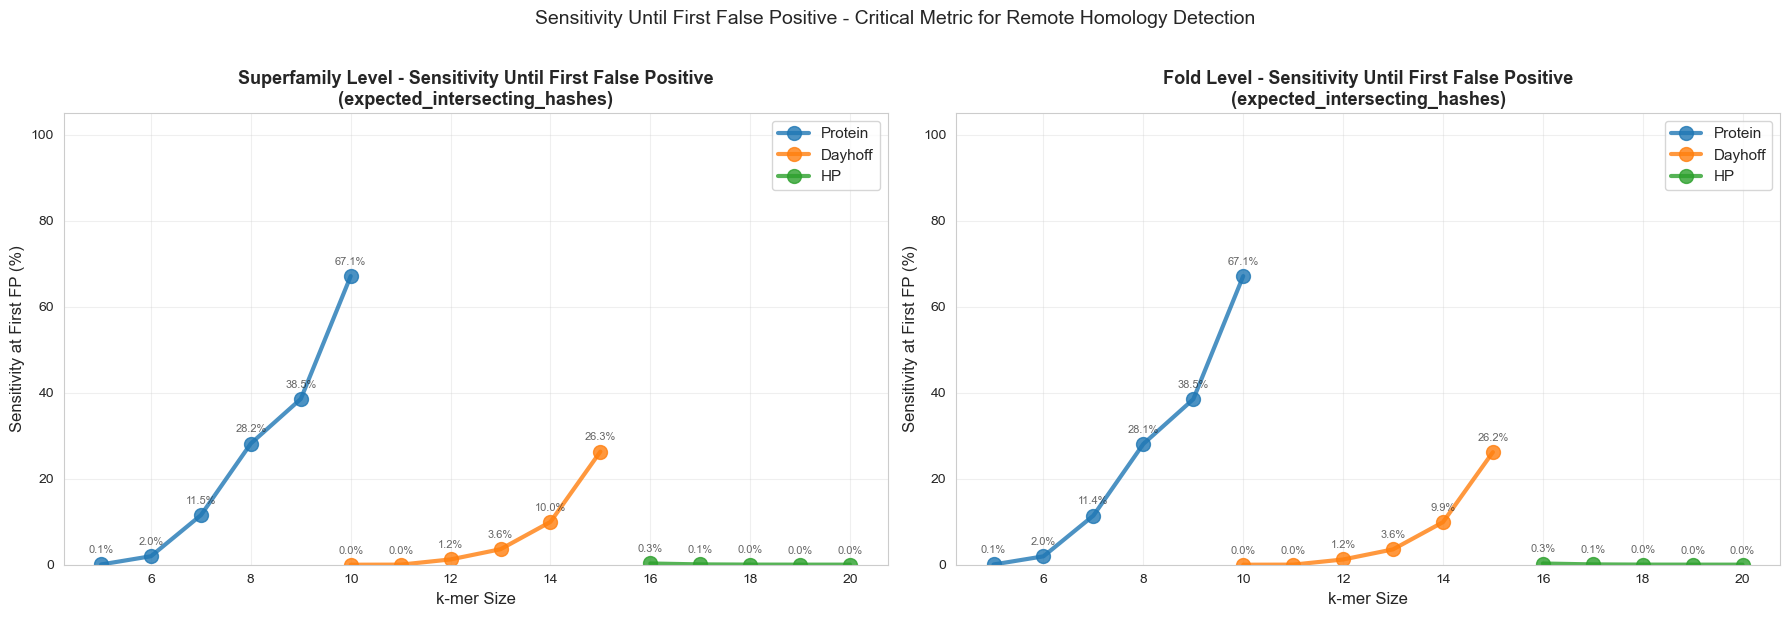


TOP PERFORMERS: SENSITIVITY UNTIL FIRST FALSE POSITIVE

SUPERFAMILY LEVEL:

Top 10 configurations:
   1. protein_k10              :  67.1% (1,251/1,864 true positives)
   2. protein_k9               :  38.5% (1,358/3,523 true positives)
   3. protein_k8               :  28.2% (2,256/8,005 true positives)
   4. dayhoff_k15              :  26.3% (1,444/5,490 true positives)
   5. protein_k7               :  11.5% (3,688/32,001 true positives)
   6. dayhoff_k14              :  10.0% (1,214/12,193 true positives)
   7. dayhoff_k13              :   3.6% (1,229/34,131 true positives)
   8. protein_k6               :   2.0% (5,798/293,680 true positives)
   9. dayhoff_k12              :   1.2% (1,393/113,169 true positives)
  10. hp_k16                   :   0.3% (27,907/9,754,047 true positives)

Best by encoding:
  Protein : protein_k10               -  67.1% (k=10)
  Dayhoff : dayhoff_k15               -  26.3% (k=15)
  HP      : hp_k16                    -   0.3% (k=16)

FOLD LEVEL:

Top

In [ ]:
# Plot sensitivity until first FP
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, level in enumerate(["Superfamily", "Fold"]):
    ax = axes[idx]
    level_data = sensitivity_df[sensitivity_df["level"] == level]

    for encoding in ["Protein", "Dayhoff", "HP"]:
        enc_data = level_data[level_data["encoding"] == encoding].sort_values("k_size")
        if len(enc_data) > 0:
            ax.plot(
                enc_data["k_size"],
                enc_data["sensitivity_at_first_fp"] * 100,
                marker="o",
                markersize=10,
                linewidth=3,
                label=encoding,
                alpha=0.8,
            )

            # Annotate points
            for _, row in enc_data.iterrows():
                ax.annotate(
                    f"{row['sensitivity_at_first_fp']*100:.1f}%",
                    xy=(row["k_size"], row["sensitivity_at_first_fp"] * 100),
                    xytext=(0, 8),
                    textcoords="offset points",
                    fontsize=8,
                    ha="center",
                    alpha=0.7,
                )

    ax.set_xlabel("k-mer Size", fontsize=12)
    ax.set_ylabel("Sensitivity at First FP (%)", fontsize=12)
    ax.set_title(
        f"{level} Level - Sensitivity Until First False Positive\n({best_metric_overall})",
        fontsize=13,
        fontweight="bold",
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])

plt.suptitle(
    "Sensitivity Until First False Positive - Critical Metric for Remote Homology Detection",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Print top performers
print("\n" + "=" * 100)
print("TOP PERFORMERS: SENSITIVITY UNTIL FIRST FALSE POSITIVE")
print("=" * 100)

for level in ["Superfamily", "Fold"]:
    print(f"\n{level.upper()} LEVEL:")
    level_data = sensitivity_df[sensitivity_df["level"] == level].sort_values(
        "sensitivity_at_first_fp", ascending=False
    )
    print(f"\nTop 10 configurations:")
    for idx, (_, row) in enumerate(level_data.head(10).iterrows(), 1):
        print(
            f"  {idx:2d}. {row['dataset']:25s}: {row['sensitivity_at_first_fp']*100:5.1f}% "
            f"({row['n_true_positives']:,}/{row['total_positives']:,} true positives)"
        )

    print(f"\nBest by encoding:")
    for encoding in ["Protein", "Dayhoff", "HP"]:
        enc_best = level_data[level_data["encoding"] == encoding].head(1)
        if len(enc_best) > 0:
            row = enc_best.iloc[0]
            print(
                f"  {encoding:8s}: {row['dataset']:25s} - {row['sensitivity_at_first_fp']*100:5.1f}% "
                f"(k={row['k_size']})"
            )

NameError: name 'roc_data_fold' is not defined

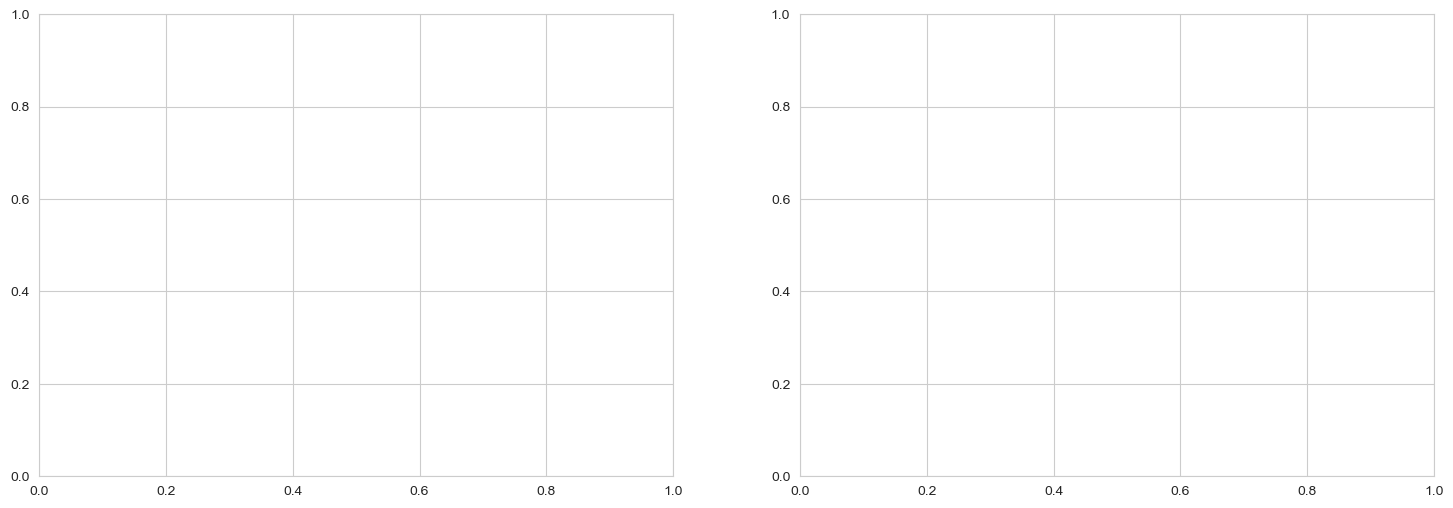

In [ ]:
# Combined comparison: AUROC vs Sensitivity at First FP
# This shows the tradeoff between overall discriminative power and early precision

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Merge AUROC data with sensitivity data
combined_metrics = []

for _, row in sensitivity_df.iterrows():
    dataset = row["dataset"]
    level = row["level"]

    # Get AUROC for this dataset
    if level == "Superfamily" and dataset in roc_data_superfamily:
        auroc = roc_data_superfamily[dataset]["auroc"]
    elif level == "Fold" and dataset in roc_data_fold:
        auroc = roc_data_fold[dataset]["auroc"]
    else:
        continue

    combined_metrics.append(
        {
            "dataset": dataset,
            "encoding": row["encoding"],
            "k_size": row["k_size"],
            "level": level,
            "auroc": auroc,
            "sensitivity_first_fp": row["sensitivity_at_first_fp"],
        }
    )

if combined_metrics:
    combined_metrics_df = pd.DataFrame(combined_metrics)

    # Plot for each level
    for idx, level in enumerate(["Superfamily", "Fold"]):
        ax = axes[idx]
        level_data = combined_metrics_df[combined_metrics_df["level"] == level]

        # Scatter plot colored by encoding
        for encoding, color in [
            ("Protein", "#1f77b4"),
            ("Dayhoff", "#ff7f0e"),
            ("HP", "#2ca02c"),
        ]:
            enc_data = level_data[level_data["encoding"] == encoding]
            if len(enc_data) > 0:
                scatter = ax.scatter(
                    enc_data["auroc"],
                    enc_data["sensitivity_first_fp"] * 100,
                    s=enc_data["k_size"] * 15,
                    c=color,
                    alpha=0.6,
                    label=encoding,
                    edgecolors="black",
                    linewidth=0.5,
                )

        # Add diagonal reference line (where AUROC = sensitivity)
        ax.plot([0.5, 1.0], [0, 50], "k--", alpha=0.3, linewidth=1)

        ax.set_xlabel("AUROC", fontsize=12)
        ax.set_ylabel("Sensitivity at First FP (%)", fontsize=12)
        ax.set_title(
            f"{level} Level: AUROC vs Early Precision\n(Point size = k-mer size)",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0.48, 1.02])
        ax.set_ylim([-2, 105])

        # Annotate best points
        best_combined = level_data.nlargest(3, "sensitivity_first_fp")
        for _, row in best_combined.iterrows():
            ax.annotate(
                f"{row['dataset']}\nk={row['k_size']}",
                xy=(row["auroc"], row["sensitivity_first_fp"] * 100),
                xytext=(10, 10),
                textcoords="offset points",
                fontsize=7,
                alpha=0.8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.4),
                arrowprops=dict(arrowstyle="->", alpha=0.5),
            )

    plt.suptitle(
        "AUROC vs Sensitivity at First FP: Performance Tradeoff Analysis",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No combined metrics data available")

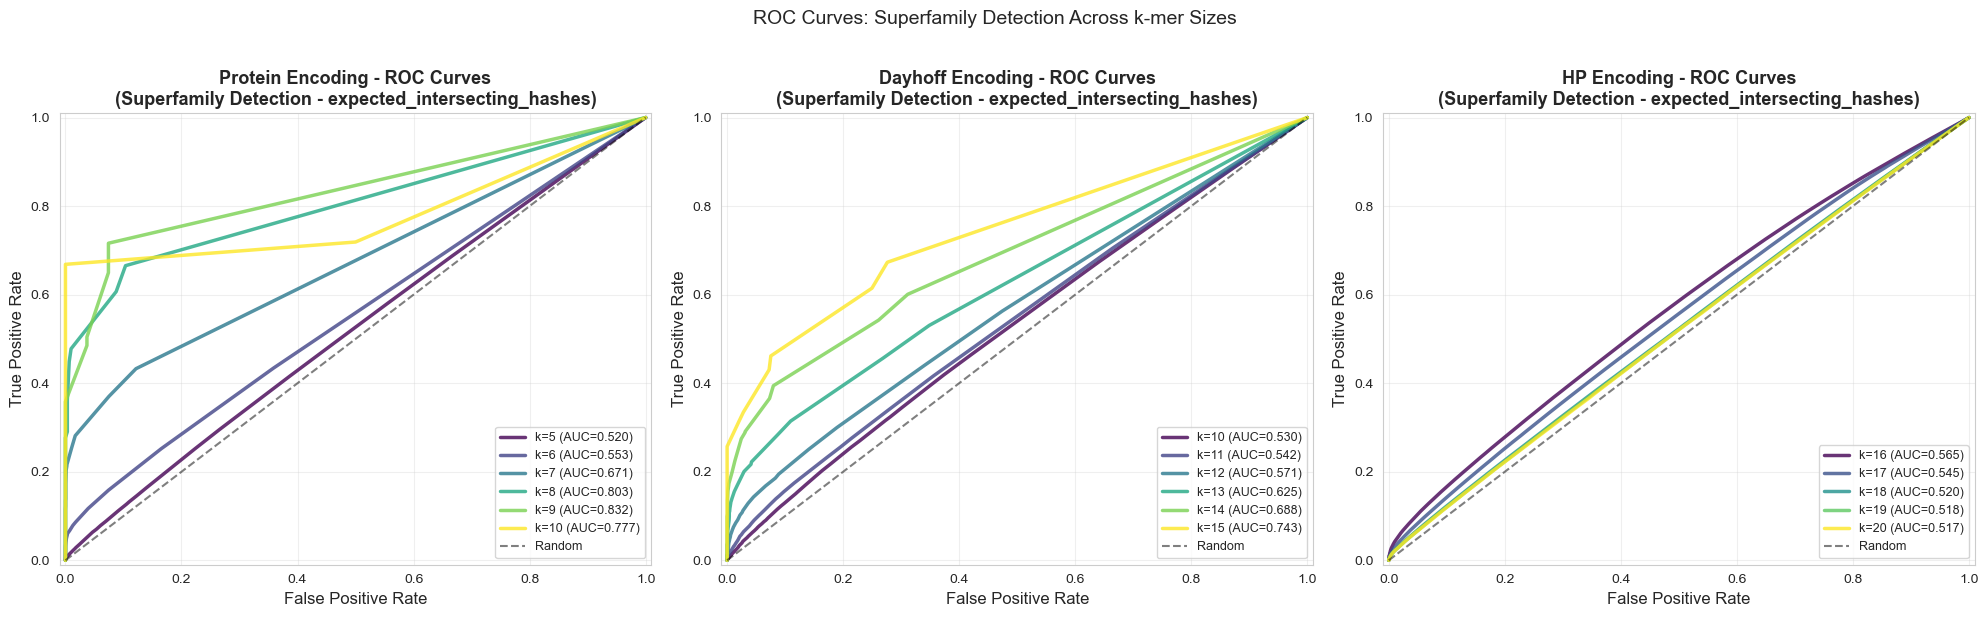

In [ ]:
# Plot ROC curves - one panel per encoding
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


for idx, encoding in enumerate(["Protein", "Dayhoff", "HP"]):
    ax = axes[idx]

    # Get all datasets for this encoding
    enc_datasets = {
        name: data
        for name, data in roc_data_superfamily.items()
        if data["encoding"] == encoding
    }

    if enc_datasets:
        # Sort by k-size
        sorted_datasets = sorted(enc_datasets.items(), key=lambda x: x[1]["k_size"])

        # Create color gradient
        k_sizes = [data["k_size"] for _, data in sorted_datasets]
        cmap = cm.get_cmap("viridis")
        norm = mcolors.Normalize(vmin=min(k_sizes), vmax=max(k_sizes))

        # Plot each ROC curve
        for dataset_name, data in sorted_datasets:
            color = cmap(norm(data["k_size"]))
            ax.plot(
                data["fpr"],
                data["tpr"],
                label=f"k={data['k_size']} (AUC={data['auroc']:.3f})",
                linewidth=2.5,
                color=color,
                alpha=0.8,
            )

        # Plot random baseline
        ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1.5, alpha=0.5)

        ax.set_xlabel("False Positive Rate", fontsize=12)
        ax.set_ylabel("True Positive Rate", fontsize=12)
        ax.set_title(
            f"{encoding} Encoding - ROC Curves\n(Superfamily Detection - {best_metric_overall})",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-0.01, 1.01])
        ax.set_ylim([-0.01, 1.01])

plt.suptitle(
    "ROC Curves: Superfamily Detection Across k-mer Sizes", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

## Additional Analyses: ROC Curves and Sensitivity

Now we'll analyze:
1. **ROC curves** for all datasets at Superfamily and Fold levels
2. **Sensitivity until first false positive** - a critical metric for remote homology detection
3. **Comparative performance** across encodings

### Metric Clarifications:

**Important Note on `expected_intersecting_hashes`:**
- **Not** the true expected value from random chance
- It's the **sum of database frequencies** for k-mers that actually match between query and target
- Conditions on the observed intersection
- **What it means:**
  - Higher values = matches are on more common k-mers
  - Lower values = matches are on rarer k-mers
  - Can calculate `average_kmer_rarity = n_intersecting_hashes / expected_intersecting_hashes`
- **Why useful for AUROC:** Helps distinguish true homologs (share both rare and common k-mers) from random matches (only share common k-mers)

## Summary and Key Findings

This notebook analyzes k-mer based protein similarity metrics across multiple encoding schemes (protein, Dayhoff, HP) and k-mer sizes.

### Key Analyses Performed:
1. **AUROC calculation** at Family, Superfamily, and Fold hierarchy levels
2. **Average metric values** comparing same-family, same-superfamily, same-fold vs different
3. **Metric distributions** visualized as density plots
4. **Filtering strategy optimization** to maximize AUROC while preserving data
5. **Cross-dataset comparison** of different encodings and k-mer sizes

### Focus Areas:
- **Superfamily level**: Detecting proteins in the same superfamily (but possibly different families)
- **Fold level**: Detecting proteins with the same fold (larger evolutionary distances)

### Metrics Analyzed:
- `jaccard`: Intersection over union
- `max_containment`: Maximum containment in either direction
- `tfidf`: TF-IDF score
- `average_kmer_frequency`: Average k-mer frequency in database
- `prob_random_cooccurrence`: Probability of random co-occurrence
- `prob_random_cooccurrence_symmetric`: Symmetric version
- `expected_intersecting_hashes`: Expected intersection by chance
- `observed_over_expected`: Ratio of observed to expected overlap